In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv("C:/Users/kavisha/OneDrive/Desktop/cbsl_daily_economic_indicators_2020_2026_preprocesd.csv")

In [2]:
df.head()

,report_date,usd_tt_buying,usd_tt_selling,gbp_tt_buying,gbp_tt_selling,eur_tt_buying,eur_tt_selling,jpy_tt_buying,jpy_tt_selling,indicative_usd_spot,...,oil_singapore_kerosene,total_energy,peak_demand,thermal_coal_pct,thermal_oil_pct,hydro_pct,wind_pct,real_gdp_growth,ncpi_yoy,ccpi_yoy
0,9/2/2020,183.83,188.13,244.7335,252.8730,217.5323,225.1715,1.7141,1.7931,187.16,...,NaN,39.25,2330.7,41.3,28.3,29.4,1.0,-1.6,6.1,4.1
1,9/3/2020,183.07,187.47,243.2002,251.1604,215.4307,223.0365,1.7076,1.7823,189.38,...,NaN,40.88,2382.0,31.7,36.8,29.2,2.3,-1.6,6.1,4.1
2,9/4/2020,183.04,187.44,242.2218,250.1649,215.7421,223.3692,1.7083,1.7830,191.69,...,NaN,43.47,2519.6,30.1,33.5,34.8,1.7,-1.6,6.1,4.1
3,9/7/2020,183.00,187.30,241.1646,249.2435,215.2957,222.9085,1.7024,1.7811,191.76,...,NaN,38.12,2310.0,39.1,22.1,35.2,3.7,-1.6,6.1,4.1
4,9/8/2020,182.44,186.84,238.9894,246.8850,214.2455,221.8617,1.7010,1.7756,189.03,...,NaN,42.72,2470.0,46.0,21.4,29.9,2.8,-1.6,6.1,4.1


In [3]:
df.shape

(1415, 28)

In [4]:
df['report_date'] = pd.to_datetime(df['report_date'])
df = df.set_index('report_date')

print("Dataset Shape:", df.shape)
print("\n--- Column Data Types & Non-Null Counts ---")
print(df.info())
print("\n--- First 5 Rows ---")
display(df.head())

# MISSING VALUES & SUMMARY STATISTICS

print("\n--- Missing Values Count & Percentage ---")
missing_df = pd.DataFrame(
    {
        "Missing Count": df.isnull().sum(),
        "Missing %": (df.isnull().sum() / len(df) * 100).round(2),
    }
)
display(missing_df[missing_df["Missing Count"] > 0])

print("\n--- Descriptive Statistics ---")
display(df.describe().T)

Dataset Shape: (1415, 27)

--- Column Data Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1415 entries, 2020-09-02 to 2026-08-10
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   usd_tt_buying           1413 non-null   float64
 1   usd_tt_selling          1413 non-null   float64
 2   gbp_tt_buying           1413 non-null   float64
 3   gbp_tt_selling          1413 non-null   float64
 4   eur_tt_buying           1413 non-null   float64
 5   eur_tt_selling          1413 non-null   float64
 6   jpy_tt_buying           1413 non-null   float64
 7   jpy_tt_selling          1413 non-null   float64
 8   indicative_usd_spot     1413 non-null   float64
 9   gold_price              871 non-null    float64
 10  overnight_liquidity     1413 non-null   float64
 11  aspi                    871 non-null    float64
 12  sp_sl20                 871 non-null    float64
 13  dail

,usd_tt_buying,usd_tt_selling,gbp_tt_buying,gbp_tt_selling,eur_tt_buying,eur_tt_selling,jpy_tt_buying,jpy_tt_selling,indicative_usd_spot,gold_price,...,oil_singapore_kerosene,total_energy,peak_demand,thermal_coal_pct,thermal_oil_pct,hydro_pct,wind_pct,real_gdp_growth,ncpi_yoy,ccpi_yoy
report_date,,,,,,,,,,,,,,,,,,,,,
2020-09-02,183.83,188.13,244.7335,252.8730,217.5323,225.1715,1.7141,1.7931,187.16,1966.12,...,NaN,39.25,2330.7,41.3,28.3,29.4,1.0,-1.6,6.1,4.1
2020-09-03,183.07,187.47,243.2002,251.1604,215.4307,223.0365,1.7076,1.7823,189.38,1949.62,...,NaN,40.88,2382.0,31.7,36.8,29.2,2.3,-1.6,6.1,4.1
2020-09-04,183.04,187.44,242.2218,250.1649,215.7421,223.3692,1.7083,1.7830,191.69,1939.67,...,NaN,43.47,2519.6,30.1,33.5,34.8,1.7,-1.6,6.1,4.1
2020-09-07,183.00,187.30,241.1646,249.2435,215.2957,222.9085,1.7024,1.7811,191.76,1938.41,...,NaN,38.12,2310.0,39.1,22.1,35.2,3.7,-1.6,6.1,4.1
2020-09-08,182.44,186.84,238.9894,246.8850,214.2455,221.8617,1.7010,1.7756,189.03,1926.49,...,NaN,42.72,2470.0,46.0,21.4,29.9,2.8,-1.6,6.1,4.1



--- Missing Values Count & Percentage ---


,Missing Count,Missing %
usd_tt_buying,2,0.14
usd_tt_selling,2,0.14
gbp_tt_buying,2,0.14
gbp_tt_selling,2,0.14
eur_tt_buying,2,0.14
eur_tt_selling,2,0.14
jpy_tt_buying,2,0.14
jpy_tt_selling,2,0.14
indicative_usd_spot,2,0.14
gold_price,544,38.45



--- Descriptive Statistics ---


,count,mean,std,min,25%,50%,75%,max
usd_tt_buying,1413.0,284.681757,56.742310,182.0200,225.2013,298.4708,318.2770,364.2270
usd_tt_selling,1413.0,293.296329,59.132956,186.3400,229.9987,306.9317,329.8014,377.4967
gbp_tt_buying,1413.0,365.499921,63.313390,231.8632,294.0615,387.8322,408.2799,459.1241
gbp_tt_selling,1413.0,379.102876,66.387123,239.5720,302.9219,404.3700,422.5120,476.4684
eur_tt_buying,1413.0,314.206938,54.321334,210.9035,249.5352,332.5239,353.6692,396.7046
eur_tt_selling,1413.0,326.598064,56.855233,218.3590,259.0090,346.8108,367.4052,412.1364
jpy_tt_buying,1413.0,2.057033,0.286438,1.6811,1.8395,1.9947,2.1570,2.8228
jpy_tt_selling,1413.0,2.139264,0.302794,1.7286,1.9074,2.0659,2.2612,2.9308
indicative_usd_spot,1413.0,313.175580,184.076976,4.1500,199.9000,303.0500,319.3120,993.3000
gold_price,871.0,1878.285029,125.699667,1623.2500,1792.6650,1861.8200,1947.8650,2407.1900


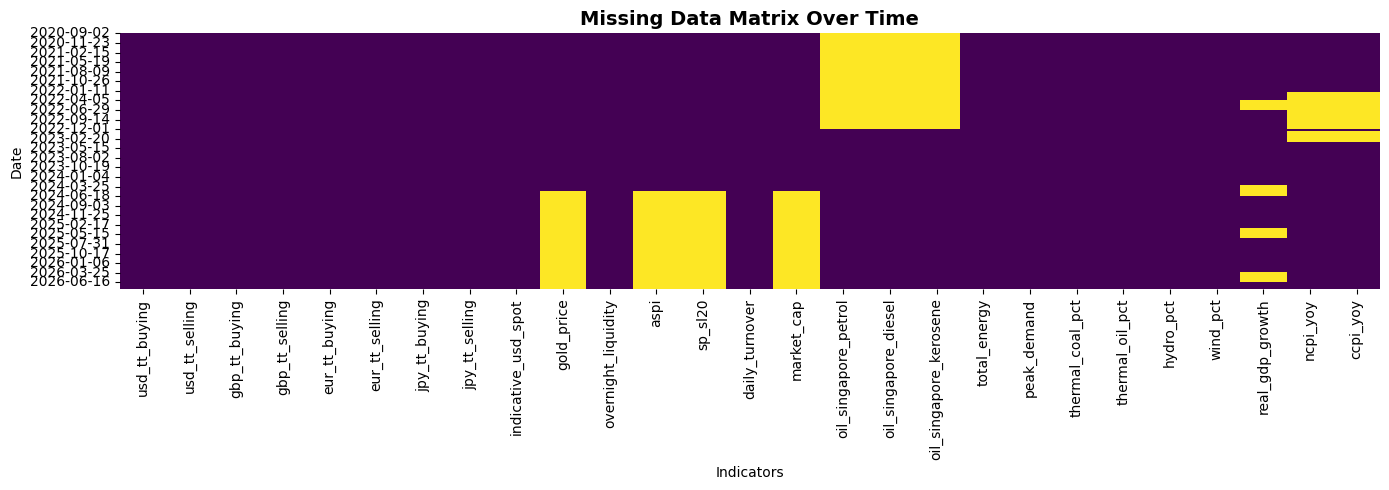

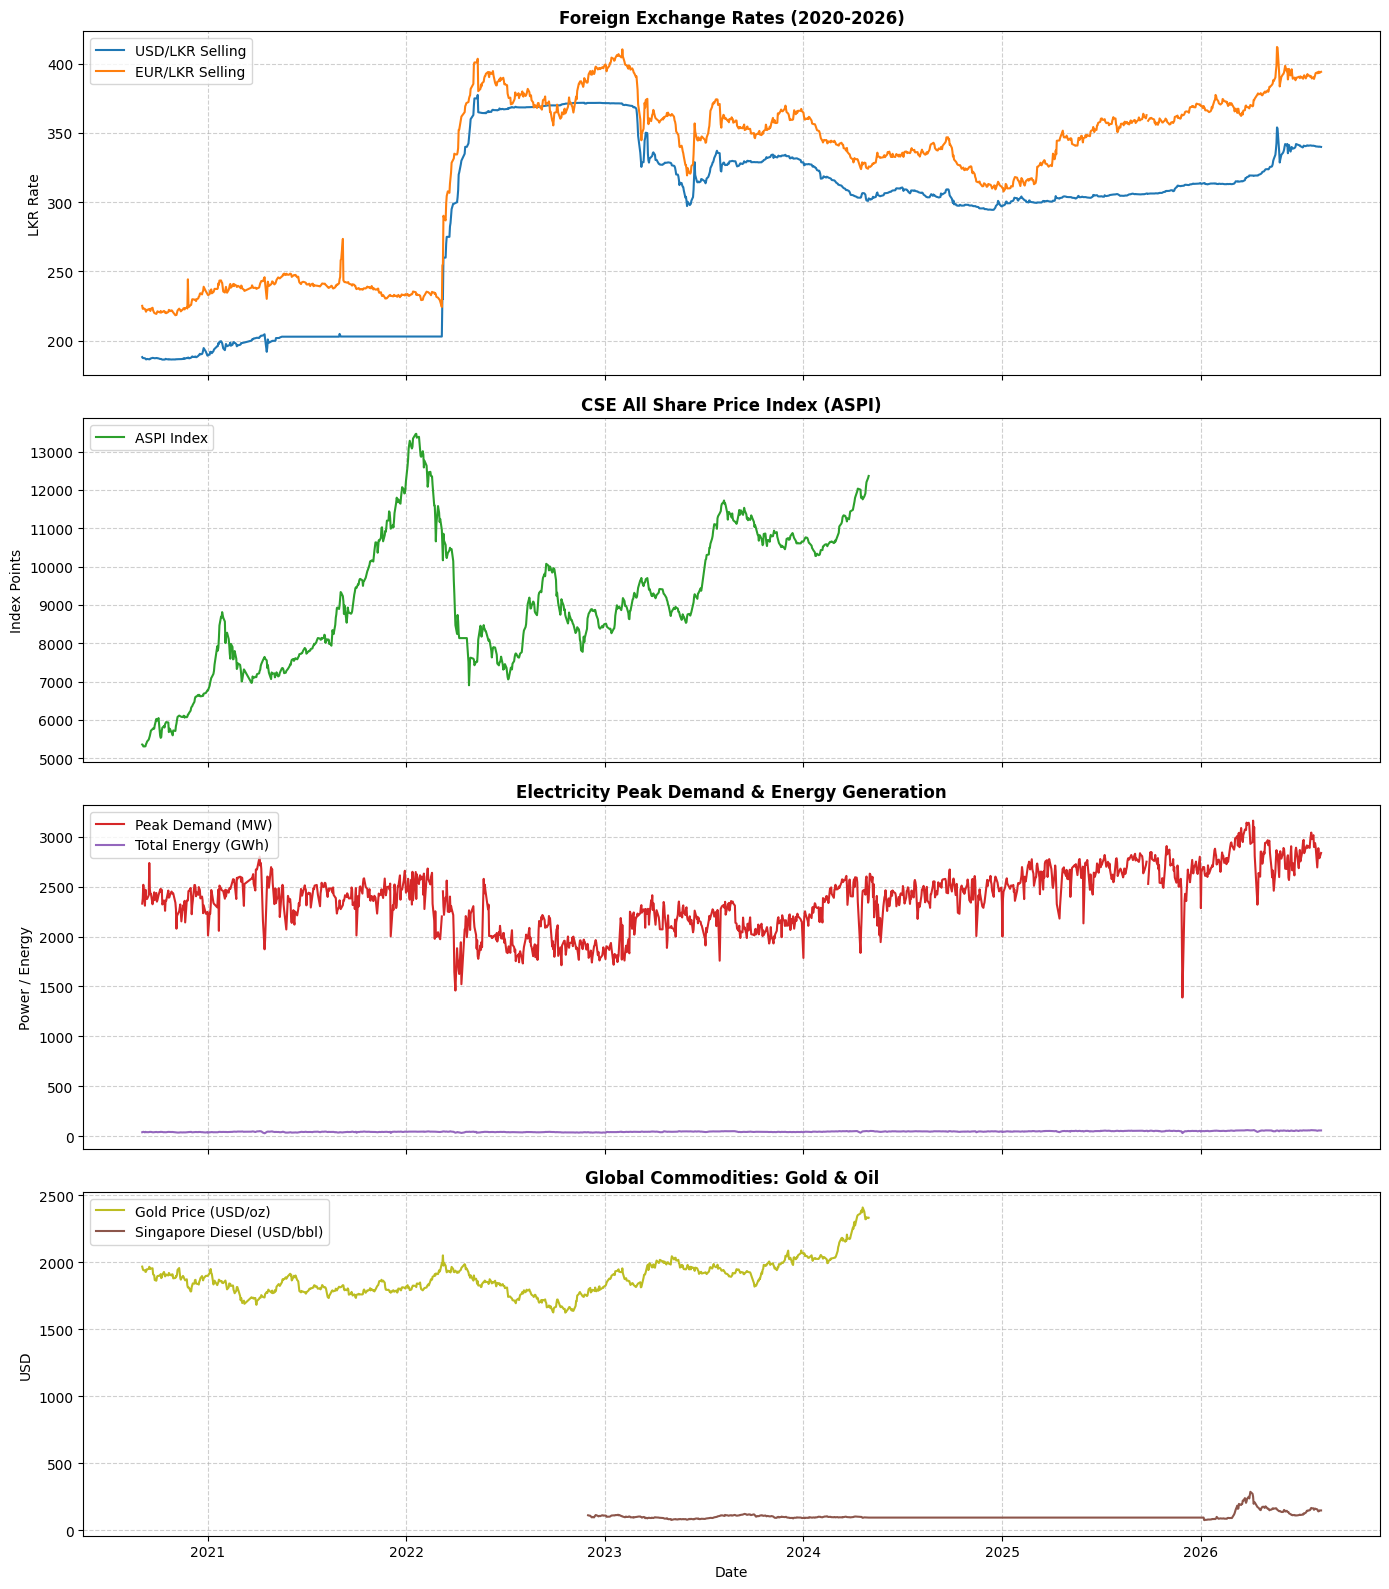

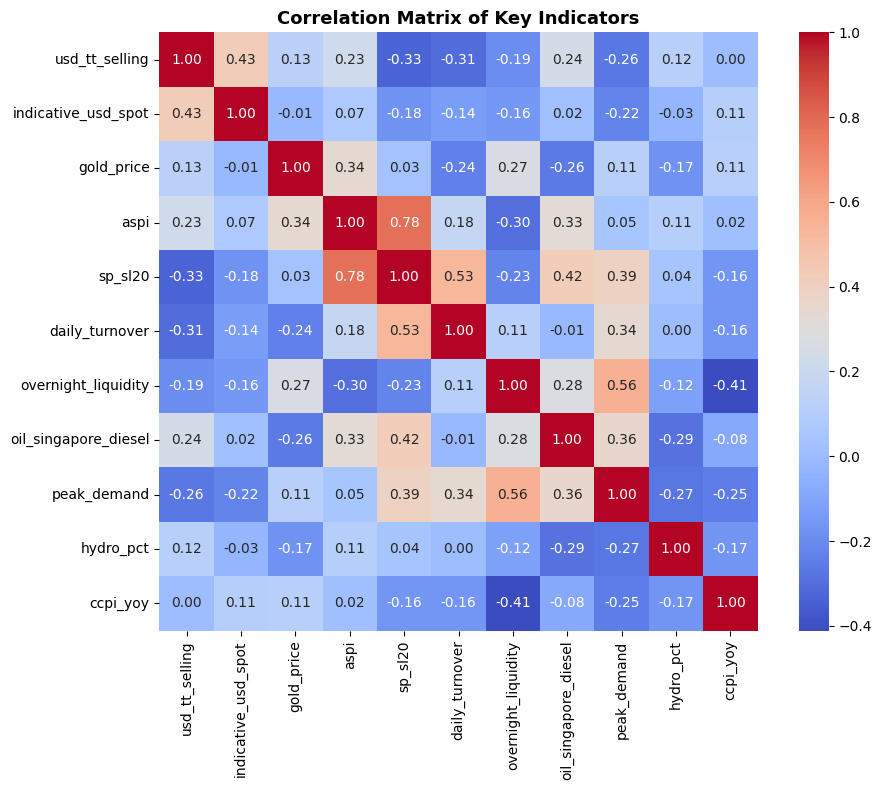

In [5]:
#  MISSING VALUE HEATMAP

plt.figure(figsize=(14, 5))
sns.heatmap(
    df.isnull().set_index(df.index.strftime("%Y-%m-%d")), # Changed df["report_date"] to df.index
    cbar=False,
    cmap="viridis",
)
plt.title("Missing Data Matrix Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Indicators")
plt.ylabel("Date")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#  TIME SERIES TRENDS (KEY MACRO INDICATORS)

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# Exchange Rates
axes[0].plot(
    df.index,
    df["usd_tt_selling"],
    label="USD/LKR Selling",
    color="#1f77b4",
)
axes[0].plot(
    df.index,
    df["eur_tt_selling"],
    label="EUR/LKR Selling",
    color="#ff7f0e",
)
axes[0].set_ylabel("LKR Rate")
axes[0].set_title(
    "Foreign Exchange Rates (2020-2026)", fontsize=12, fontweight="bold"
)
axes[0].legend(loc="upper left")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Colombo Stock Exchange (ASPI)
axes[1].plot(
    df.index, df["aspi"], label="ASPI Index", color="#2ca02c"
)
axes[1].set_ylabel("Index Points")
axes[1].set_title(
    "CSE All Share Price Index (ASPI)", fontsize=12, fontweight="bold"
)
axes[1].legend(loc="upper left")
axes[1].grid(True, linestyle="--", alpha=0.6)

# Energy Demand
axes[2].plot(
    df.index,
    df["peak_demand"],
    label="Peak Demand (MW)",
    color="#d62728",
)
axes[2].plot(
    df.index,
    df["total_energy"],
    label="Total Energy (GWh)",
    color="#9467bd",
)
axes[2].set_ylabel("Power / Energy")
axes[2].set_title(
    "Electricity Peak Demand & Energy Generation", fontsize=12, fontweight="bold"
)
axes[2].legend(loc="upper left")
axes[2].grid(True, linestyle="--", alpha=0.6)

# Global Commodities
axes[3].plot(
    df.index,
    df["gold_price"],
    label="Gold Price (USD/oz)",
    color="#bcbd22",
)
axes[3].plot(
    df.index,
    df["oil_singapore_diesel"],
    label="Singapore Diesel (USD/bbl)",
    color="#8c564b",
)
axes[3].set_ylabel("USD")
axes[3].set_title(
    "Global Commodities: Gold & Oil", fontsize=12, fontweight="bold"
)
axes[3].set_xlabel("Date")
axes[3].legend(loc="upper left")
axes[3].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


# CORRELATION MATRIX (KEY FEATURES)

key_cols = [
    "usd_tt_selling",
    "indicative_usd_spot",
    "gold_price",
    "aspi",
    "sp_sl20",
    "daily_turnover",
    "overnight_liquidity",
    "oil_singapore_diesel",
    "peak_demand",
    "hydro_pct",
    "ccpi_yoy",
]

plt.figure(figsize=(10, 8))
corr = df[key_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Correlation Matrix of Key Indicators", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

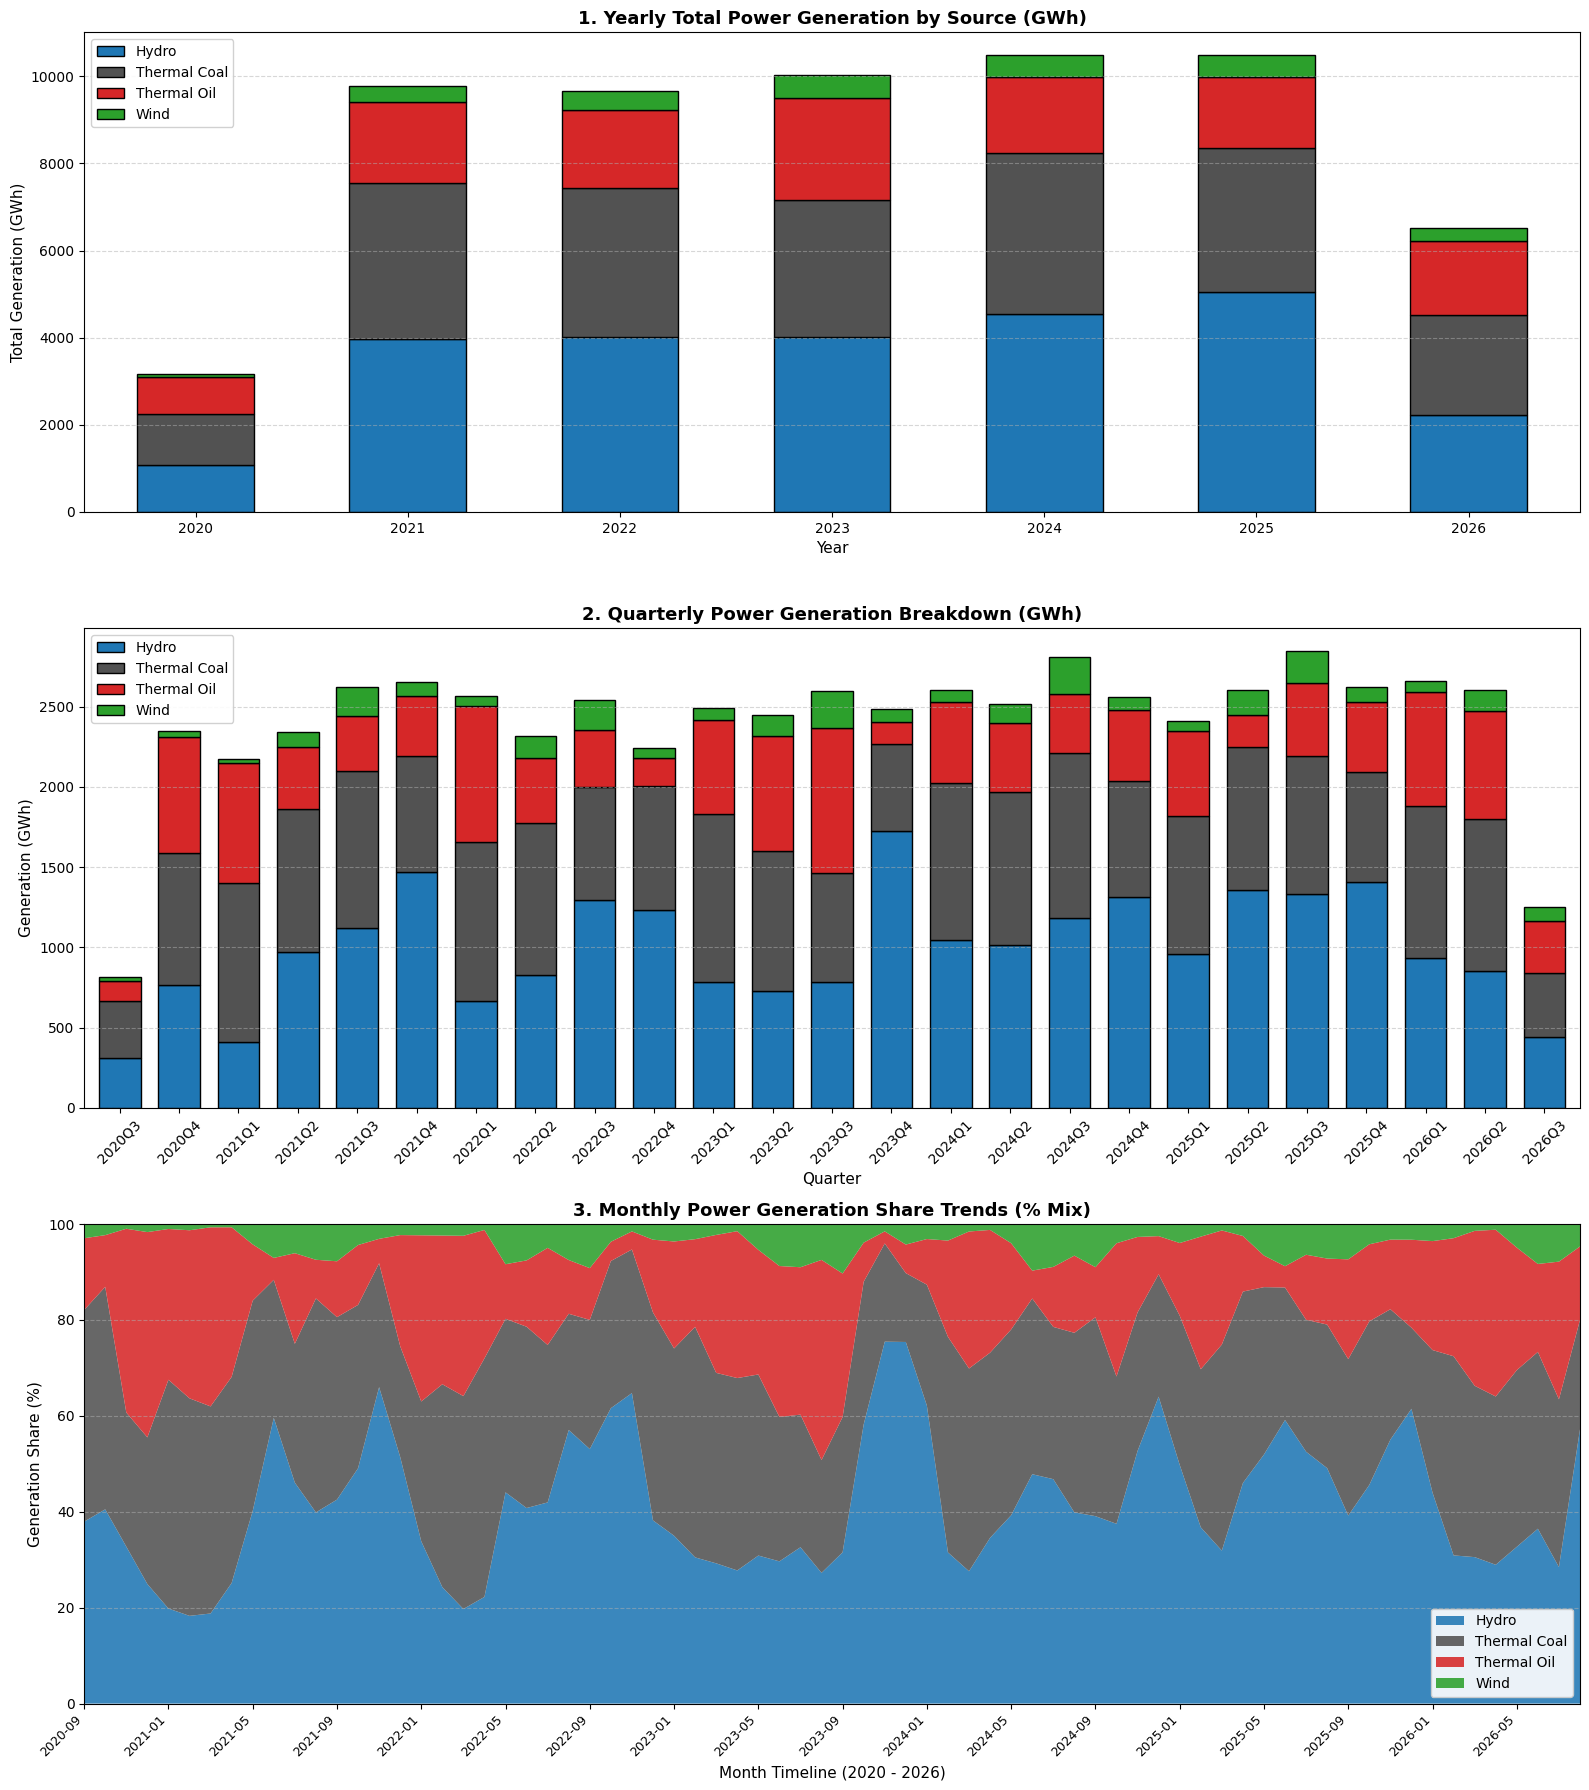

ANNUAL GENERATION SHARE SUMMARY (%)


,hydro_pct,thermal_coal_pct,thermal_oil_pct,wind_pct
year,,,,
2020,33.95,37.16,26.92,1.98
2021,40.87,36.67,18.45,4.01
2022,42.13,35.17,17.64,4.61
2023,38.24,29.63,21.47,4.78
2024,40.78,32.71,15.38,4.44
2025,42.42,27.51,13.49,4.25
2026,28.02,28.72,21.28,3.60


In [6]:

# POWER GENERATION METHODS COMPARISON (MONTHLY, QUARTERLY, YEARLY)

# LOAD AND PREPARE DATA
file_name = "C:/Users/kavisha/OneDrive/Desktop/cbsl_daily_economic_indicators_2020_2026_preprocesd.csv"
df = pd.read_csv(file_name)
df["report_date"] = pd.to_datetime(df["report_date"])
df = df.sort_values("report_date").reset_index(drop=True)

# Impute missing generation columns
energy_pct_cols = [
    "hydro_pct",
    "thermal_coal_pct",
    "thermal_oil_pct",
    "wind_pct",
]
df[energy_pct_cols + ["total_energy"]] = (
    df[energy_pct_cols + ["total_energy"]].ffill().bfill()
)

# Convert % shares to actual generation volume in Gigawatt-hours (GWh)
for col in energy_pct_cols:
  gwh_col = col.replace("_pct", "_gwh")
  df[gwh_col] = (df[col] / 100) * df["total_energy"]

gwh_cols = ["hydro_gwh", "thermal_coal_gwh", "thermal_oil_gwh", "wind_gwh"]
source_labels = ["Hydro", "Thermal Coal", "Thermal Oil", "Wind"]
color_palette = ["#1f77b4", "#525252", "#d62728", "#2ca02c"]

# TIME PERIOD EXTRACTION & AGGREGATIONS
df["year"] = df["report_date"].dt.year
df["year_quarter"] = df["report_date"].dt.to_period("Q").astype(str)
df["year_month"] = df["report_date"].dt.to_period("M").astype(str)

# Aggregate generation volume (Sum GWh)
yearly_gwh = df.groupby("year")[gwh_cols].sum()
quarterly_gwh = df.groupby("year_quarter")[gwh_cols].sum()
monthly_gwh = df.groupby("year_month")[gwh_cols].sum()

# Aggregate average percentage share (%)
yearly_pct = df.groupby("year")[energy_pct_cols].mean()
quarterly_pct = df.groupby("year_quarter")[energy_pct_cols].mean()
monthly_pct = df.groupby("year_month")[energy_pct_cols].mean()

fig, axes = plt.subplots(3, 1, figsize=(16, 18))

# PANEL 1: YEARLY TOTAL POWER GENERATION (GWh)

yearly_gwh.plot(
    kind="bar",
    stacked=True,
    color=color_palette,
    ax=axes[0],
    edgecolor="black",
    width=0.55,
)
axes[0].set_title(
    "1. Yearly Total Power Generation by Source (GWh)",
    fontsize=13,
    fontweight="bold",
)
axes[0].set_ylabel("Total Generation (GWh)", fontsize=11)
axes[0].set_xlabel("Year", fontsize=11)
axes[0].legend(source_labels, loc="upper left", framealpha=0.9)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)
axes[0].tick_params(axis="x", rotation=0)

# PANEL 2: QUARTERLY POWER GENERATION DYNAMICS (GWh)
quarterly_gwh.plot(
    kind="bar",
    stacked=True,
    color=color_palette,
    ax=axes[1],
    edgecolor="black",
    width=0.7,
)
axes[1].set_title(
    "2. Quarterly Power Generation Breakdown (GWh)",
    fontsize=13,
    fontweight="bold",
)
axes[1].set_ylabel("Generation (GWh)", fontsize=11)
axes[1].set_xlabel("Quarter", fontsize=11)
axes[1].legend(source_labels, loc="upper left", framealpha=0.9)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)
axes[1].tick_params(axis="x", rotation=45)

# PANEL 3: MONTHLY POWER GENERATION MIX (100% SHARE BREAKDOWN)
monthly_pct_100 = monthly_pct.div(monthly_pct.sum(axis=1), axis=0) * 100
axes[2].stackplot(
    range(len(monthly_pct_100)),
    monthly_pct_100["hydro_pct"],
    monthly_pct_100["thermal_coal_pct"],
    monthly_pct_100["thermal_oil_pct"],
    monthly_pct_100["wind_pct"],
    labels=source_labels,
    colors=color_palette,
    alpha=0.88,
)
axes[2].set_title(
    "3. Monthly Power Generation Share Trends (% Mix)",
    fontsize=13,
    fontweight="bold",
)
axes[2].set_ylabel("Generation Share (%)", fontsize=11)
axes[2].set_xlabel("Month Timeline (2020 - 2026)", fontsize=11)
axes[2].set_xlim(0, len(monthly_pct_100) - 1)
axes[2].set_ylim(0, 100)
axes[2].set_xticks(range(0, len(monthly_pct_100), 4))
axes[2].set_xticklabels(
    monthly_pct_100.index[::4], rotation=45, ha="right", fontsize=9
)
axes[2].legend(loc="lower right", framealpha=0.9)
axes[2].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# SUMMARY METRIC TABLES FOR CAPSTONE REPORT
print("=" * 70)
print("ANNUAL GENERATION SHARE SUMMARY (%)")
print("=" * 70)
display(yearly_pct.round(2))

C:\Users\kavisha\AppData\Local\Temp\ipykernel_5168\3800331004.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="year", y="peak_demand", palette="Blues", ax=ax3)
C:\Users\kavisha\AppData\Local\Temp\ipykernel_5168\3800331004.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=fuel_df, x="Product", y="Price", palette=["#3182CE", "#DD6B20", "#805AD5"], ax=ax4, inner="quartile", cut=0)
C:\Users\kavisha\AppData\Local\Temp\ipykernel_5168\3800331004.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


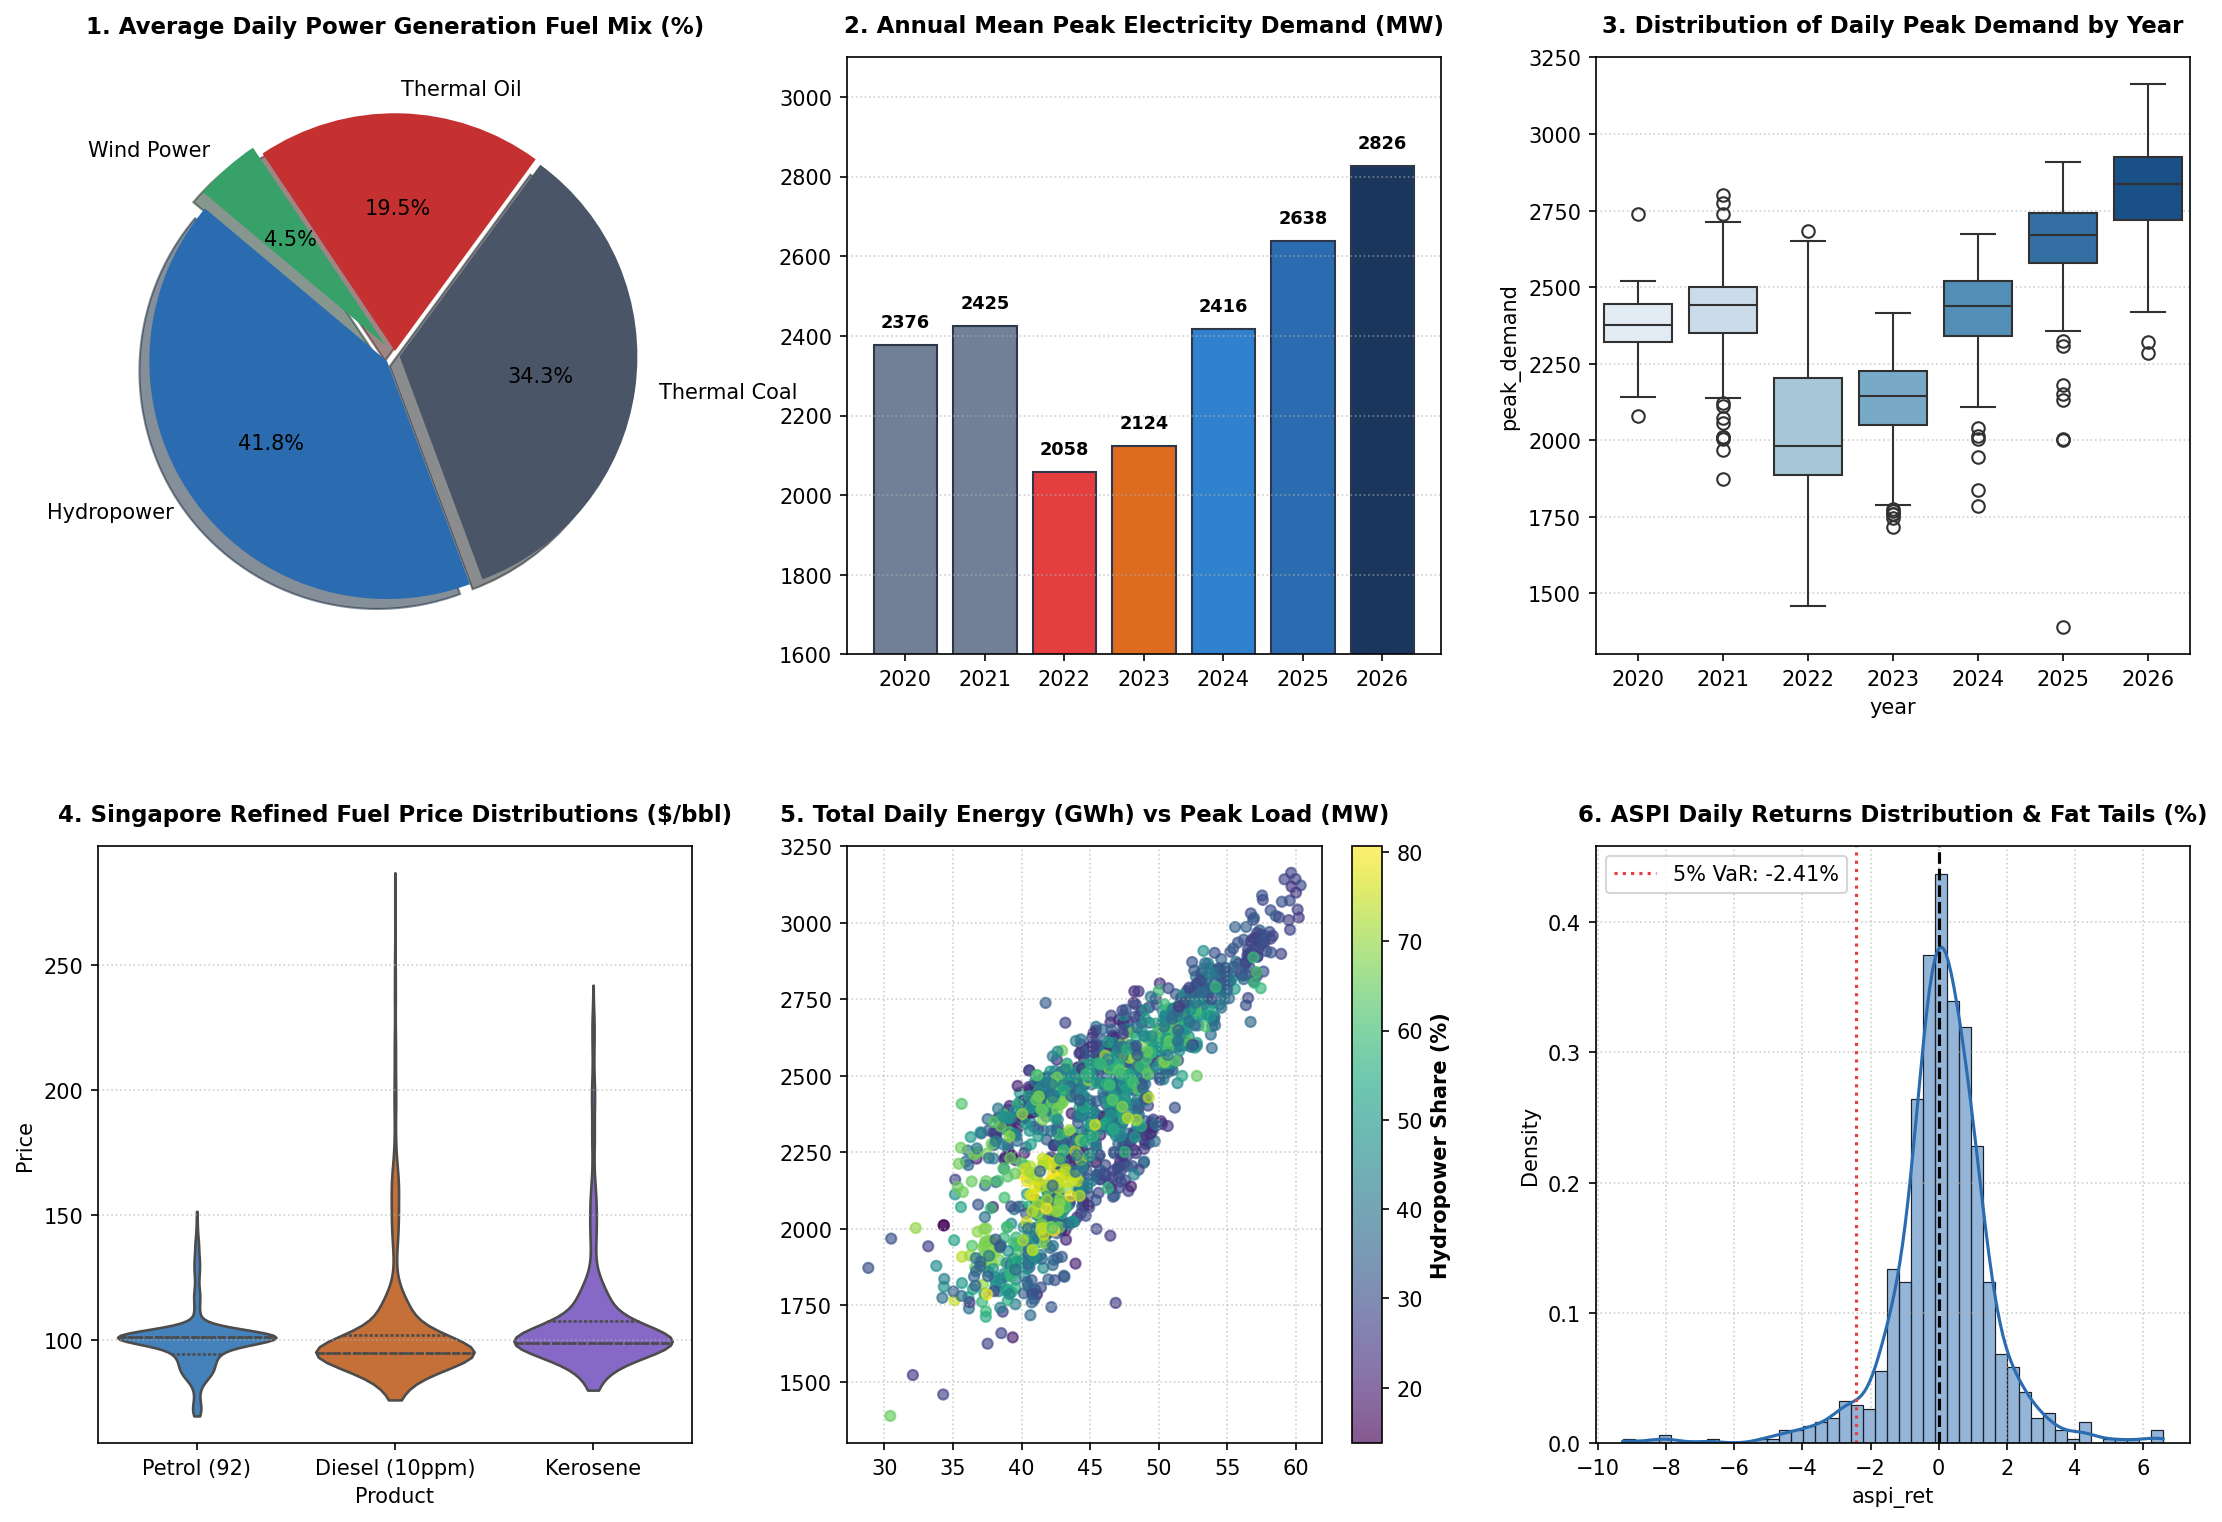

In [7]:
#  Load data & correct parsing anomalies
df = pd.read_csv("C:/Users/kavisha/OneDrive/Desktop/cbsl_daily_economic_indicators_2020_2026_preprocesd.csv")
df["report_date"] = pd.to_datetime(df["report_date"], format="%m/%d/%Y", errors="coerce")
df = df.sort_values("report_date").reset_index(drop=True)

mid_usd = (df["usd_tt_buying"] + df["usd_tt_selling"]) / 2.0
spot_anomaly = (
    (df["indicative_usd_spot"] < df["usd_tt_buying"] * 0.90)
    | (df["indicative_usd_spot"] > df["usd_tt_selling"] * 1.10)
    | df["indicative_usd_spot"].isnull()
)
df.loc[spot_anomaly, "indicative_usd_spot"] = mid_usd[spot_anomaly]

energy_cols = ["thermal_coal_pct", "thermal_oil_pct", "hydro_pct", "wind_pct"]
df[energy_cols] = df[energy_cols].clip(lower=0.0)
energy_sum = df[energy_cols].sum(axis=1)
for c in energy_cols:
    df[c] = np.where(energy_sum > 0, (df[c] / energy_sum) * 100.0, df[c])

df["year"] = df["report_date"].dt.year
df["aspi_ret"] = np.log(df["aspi"] / df["aspi"].shift(1)) * 100

#  Master 6-Panel Visualization
fig = plt.figure(figsize=(18, 12), dpi=150)
gs = fig.add_gridspec(2, 3, hspace=0.32, wspace=0.26)

# (1) Pie Chart
ax1 = fig.add_subplot(gs[0, 0])
fuel_shares = [df["hydro_pct"].mean(), df["thermal_coal_pct"].mean(), df["thermal_oil_pct"].mean(), df["wind_pct"].mean()]
ax1.pie(fuel_shares, labels=["Hydropower", "Thermal Coal", "Thermal Oil", "Wind Power"], autopct="%1.1f%%",
        startangle=140, colors=["#2B6CB0", "#4A5568", "#C53030", "#38A169"], explode=(0.04, 0.02, 0.02, 0.06), shadow=True)
ax1.set_title("1. Average Daily Power Generation Fuel Mix (%)", fontsize=11, fontweight="bold", pad=12)

# (2) Bar Chart
ax2 = fig.add_subplot(gs[0, 1])
yearly_demand = df.groupby("year")["peak_demand"].mean()
bars = ax2.bar([str(y) for y in yearly_demand.index], yearly_demand.values, color=["#718096", "#718096", "#E53E3E", "#DD6B20", "#3182CE", "#2B6CB0", "#1A365D"], edgecolor="#2D3748")
for b in bars:
    ax2.text(b.get_x() + b.get_width()/2.0, b.get_height() + 35, f"{b.get_height():.0f}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")
ax2.set_title("2. Annual Mean Peak Electricity Demand (MW)", fontsize=11, fontweight="bold", pad=12)
ax2.set_ylim(1600, 3100)
ax2.grid(axis="y", linestyle=":", alpha=0.6)

# (3) Box Plot
ax3 = fig.add_subplot(gs[0, 2])
sns.boxplot(data=df, x="year", y="peak_demand", palette="Blues", ax=ax3)
ax3.set_title("3. Distribution of Daily Peak Demand by Year", fontsize=11, fontweight="bold", pad=12)
ax3.grid(axis="y", linestyle=":", alpha=0.6)

# (4) Violin Plot
ax4 = fig.add_subplot(gs[1, 0])
fuel_df = df[["oil_singapore_petrol", "oil_singapore_diesel", "oil_singapore_kerosene"]].dropna().melt(var_name="Product", value_name="Price")
fuel_df["Product"] = fuel_df["Product"].map({"oil_singapore_petrol": "Petrol (92)", "oil_singapore_diesel": "Diesel (10ppm)", "oil_singapore_kerosene": "Kerosene"})
sns.violinplot(data=fuel_df, x="Product", y="Price", palette=["#3182CE", "#DD6B20", "#805AD5"], ax=ax4, inner="quartile", cut=0)
ax4.set_title("4. Singapore Refined Fuel Price Distributions ($/bbl)", fontsize=11, fontweight="bold", pad=12)
ax4.grid(axis="y", linestyle=":", alpha=0.6)

# (5) Scatter Plot
ax5 = fig.add_subplot(gs[1, 1])
sc = ax5.scatter(df["total_energy"], df["peak_demand"], c=df["hydro_pct"], cmap="viridis", alpha=0.65, s=24)
plt.colorbar(sc, ax=ax5).set_label("Hydropower Share (%)", fontweight="bold")
ax5.set_title("5. Total Daily Energy (GWh) vs Peak Load (MW)", fontsize=11, fontweight="bold", pad=12)
ax5.grid(True, linestyle=":", alpha=0.6)

# (6) Histogram + KDE
ax6 = fig.add_subplot(gs[1, 2])
valid_ret = df["aspi_ret"].dropna()
sns.histplot(valid_ret, bins=45, kde=True, color="#2B6CB0", edgecolor="#1A202C", ax=ax6, stat="density")
ax6.axvline(0, color="black", linestyle="--")
ax6.axvline(valid_ret.quantile(0.05), color="#E53E3E", linestyle=":", label=f"5% VaR: {valid_ret.quantile(0.05):.2f}%")
ax6.set_title("6. ASPI Daily Returns Distribution & Fat Tails (%)", fontsize=11, fontweight="bold", pad=12)
ax6.legend()
ax6.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

In [8]:
# LOAD RAW DATA & BASE CLEANING

file_name = "C:/Users/kavisha/OneDrive/Desktop/cbsl_daily_economic_indicators_2020_2026_preprocesd.csv"
df = pd.read_csv(file_name)
df["report_date"] = pd.to_datetime(df["report_date"], format="%m/%d/%Y", errors="coerce")
df = df.sort_values("report_date").reset_index(drop=True)

# Correct spot USD parsing anomaly
mid_usd = (df["usd_tt_buying"] + df["usd_tt_selling"]) / 2.0
spot_anomaly = (
    (df["indicative_usd_spot"] < df["usd_tt_buying"] * 0.90)
    | (df["indicative_usd_spot"] > df["usd_tt_selling"] * 1.10)
    | df["indicative_usd_spot"].isnull()
)
df.loc[spot_anomaly, "indicative_usd_spot"] = mid_usd[spot_anomaly]

# Correct inflation bleed into GDP column
gdp_anomaly = df["real_gdp_growth"].abs() > 20.0
df.loc[gdp_anomaly & df["ccpi_yoy"].isnull(), "ccpi_yoy"] = df.loc[gdp_anomaly, "real_gdp_growth"]
df.loc[gdp_anomaly, "real_gdp_growth"] = np.nan

# Normalize energy generation mix to sum to 100%
energy_cols = ["thermal_coal_pct", "thermal_oil_pct", "hydro_pct", "wind_pct"]
df[energy_cols] = df[energy_cols].clip(lower=0.0)
energy_sum = df[energy_cols].sum(axis=1)
for c in energy_cols:
    df[c] = np.where(energy_sum > 0, (df[c] / energy_sum) * 100.0, df[c])

# Cyclical calendar features
df["sin_dow"] = np.sin(2 * np.pi * df["report_date"].dt.dayofweek / 5.0)
df["cos_dow"] = np.cos(2 * np.pi * df["report_date"].dt.dayofweek / 5.0)
df["sin_month"] = np.sin(2 * np.pi * df["report_date"].dt.month / 12.0)
df["cos_month"] = np.cos(2 * np.pi * df["report_date"].dt.month / 12.0)

# TRACK 1: EQUITIES & GOLD DATAFRAME (Sep 2020 – Apr 2024)

t1_cols = [
    "report_date", "aspi", "sp_sl20", "market_cap", "gold_price",
    "usd_tt_buying", "usd_tt_selling", "indicative_usd_spot",
    "overnight_liquidity", "daily_turnover",
    "real_gdp_growth", "ncpi_yoy", "ccpi_yoy",
    "sin_dow", "cos_dow", "sin_month", "cos_month"
]

df_equities_gold = df[t1_cols].dropna(subset=["aspi", "gold_price"]).copy().reset_index(drop=True)

# Step-wise forward fill only for published monthly/quarterly macro series
df_equities_gold[["real_gdp_growth", "ncpi_yoy", "ccpi_yoy"]] = (
    df_equities_gold[["real_gdp_growth", "ncpi_yoy", "ccpi_yoy"]].ffill().bfill()
)

# Feature engineering (strictly shifted to t-1 to prevent lookahead bias)
df_equities_gold["aspi_lag_1"] = df_equities_gold["aspi"].shift(1)
df_equities_gold["aspi_lag_5"] = df_equities_gold["aspi"].shift(5)
df_equities_gold["aspi_ma_5"] = df_equities_gold["aspi"].shift(1).rolling(5).mean()
df_equities_gold["aspi_ma_20"] = df_equities_gold["aspi"].shift(1).rolling(20).mean()
df_equities_gold["aspi_vol_10"] = np.log(df_equities_gold["aspi"] / df_equities_gold["aspi"].shift(1)).shift(1).rolling(10).std()
df_equities_gold["usd_lag_1"] = df_equities_gold["usd_tt_selling"].shift(1)
df_equities_gold["gold_lag_1"] = df_equities_gold["gold_price"].shift(1)
df_equities_gold["sp_to_aspi_ratio"] = df_equities_gold["sp_sl20"] / df_equities_gold["aspi"]

df_equities_gold = df_equities_gold.dropna().reset_index(drop=True)


# TRACK 2: POWER GRID & PEAK DEMAND DATAFRAME (Sep 2020 – Aug 2026)

t2_cols = [
    "report_date", "peak_demand", "total_energy",
    "thermal_coal_pct", "thermal_oil_pct", "hydro_pct", "wind_pct",
    "usd_tt_selling", "overnight_liquidity",
    "sin_dow", "cos_dow", "sin_month", "cos_month"
]

df_electricity = df[t2_cols].dropna(subset=["peak_demand", "total_energy"]).copy().reset_index(drop=True)

# Grid technical features
df_electricity["demand_lag_1"] = df_electricity["peak_demand"].shift(1)
df_electricity["demand_lag_7"] = df_electricity["peak_demand"].shift(7)
df_electricity["demand_ma_7"] = df_electricity["peak_demand"].shift(1).rolling(7).mean()
df_electricity["total_energy_lag_1"] = df_electricity["total_energy"].shift(1)
df_electricity["hydro_share_lag_1"] = (df_electricity["hydro_pct"] + df_electricity["wind_pct"]).shift(1)
df_electricity["coal_pct_lag_1"] = df_electricity["thermal_coal_pct"].shift(1)

df_electricity = df_electricity.dropna().reset_index(drop=True)


# TRACK 3: SINGAPORE REFINED FUEL DATAFRAME (Dec 2022 – Aug 2026)

t3_cols = [
    "report_date", "oil_singapore_petrol", "oil_singapore_diesel", "oil_singapore_kerosene",
    "usd_tt_selling", "thermal_oil_pct", "total_energy",
    "sin_dow", "cos_dow", "sin_month", "cos_month"
]

df_refined_fuel = df[t3_cols].dropna(subset=["oil_singapore_petrol", "oil_singapore_diesel"]).copy().reset_index(drop=True)

# Fuel price lag features
df_refined_fuel["diesel_lag_1"] = df_refined_fuel["oil_singapore_diesel"].shift(1)
df_refined_fuel["petrol_lag_1"] = df_refined_fuel["oil_singapore_petrol"].shift(1)
df_refined_fuel["kerosene_lag_1"] = df_refined_fuel["oil_singapore_kerosene"].shift(1)
df_refined_fuel["diesel_ma_7"] = df_refined_fuel["oil_singapore_diesel"].shift(1).rolling(7).mean()
df_refined_fuel["thermal_oil_lag_1"] = df_refined_fuel["thermal_oil_pct"].shift(1)
df_refined_fuel["usd_lag_1"] = df_refined_fuel["usd_tt_selling"].shift(1)

df_refined_fuel = df_refined_fuel.dropna().reset_index(drop=True)

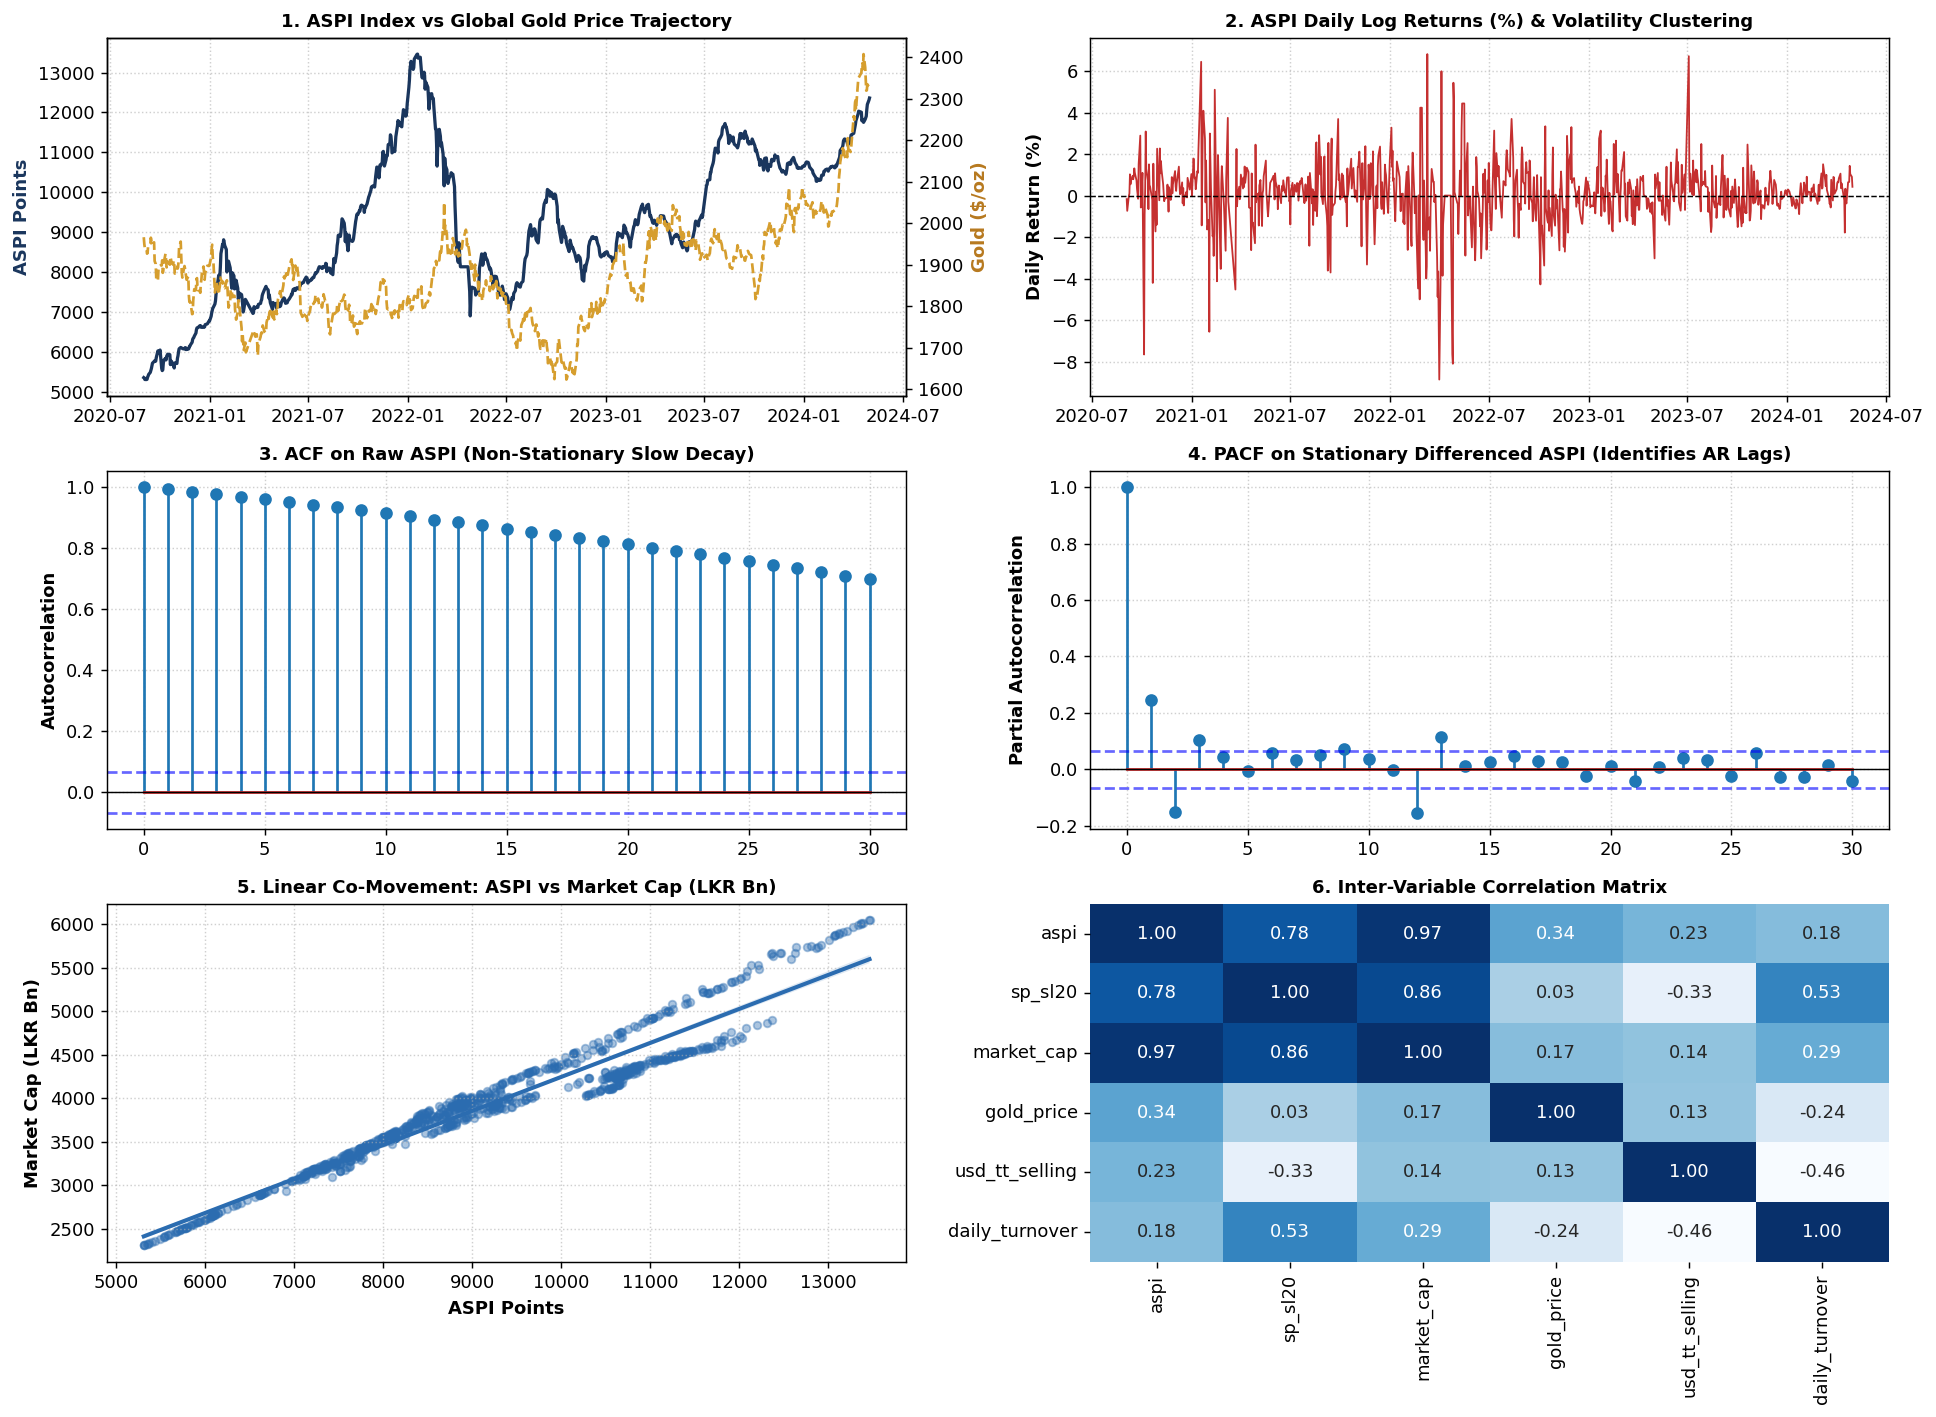

C:\Users\kavisha\AppData\Local\Temp\ipykernel_5168\3155777082.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_t2, x="day_name", y="peak_demand", order=day_order, ax=axes[1, 0], palette="Blues_r")


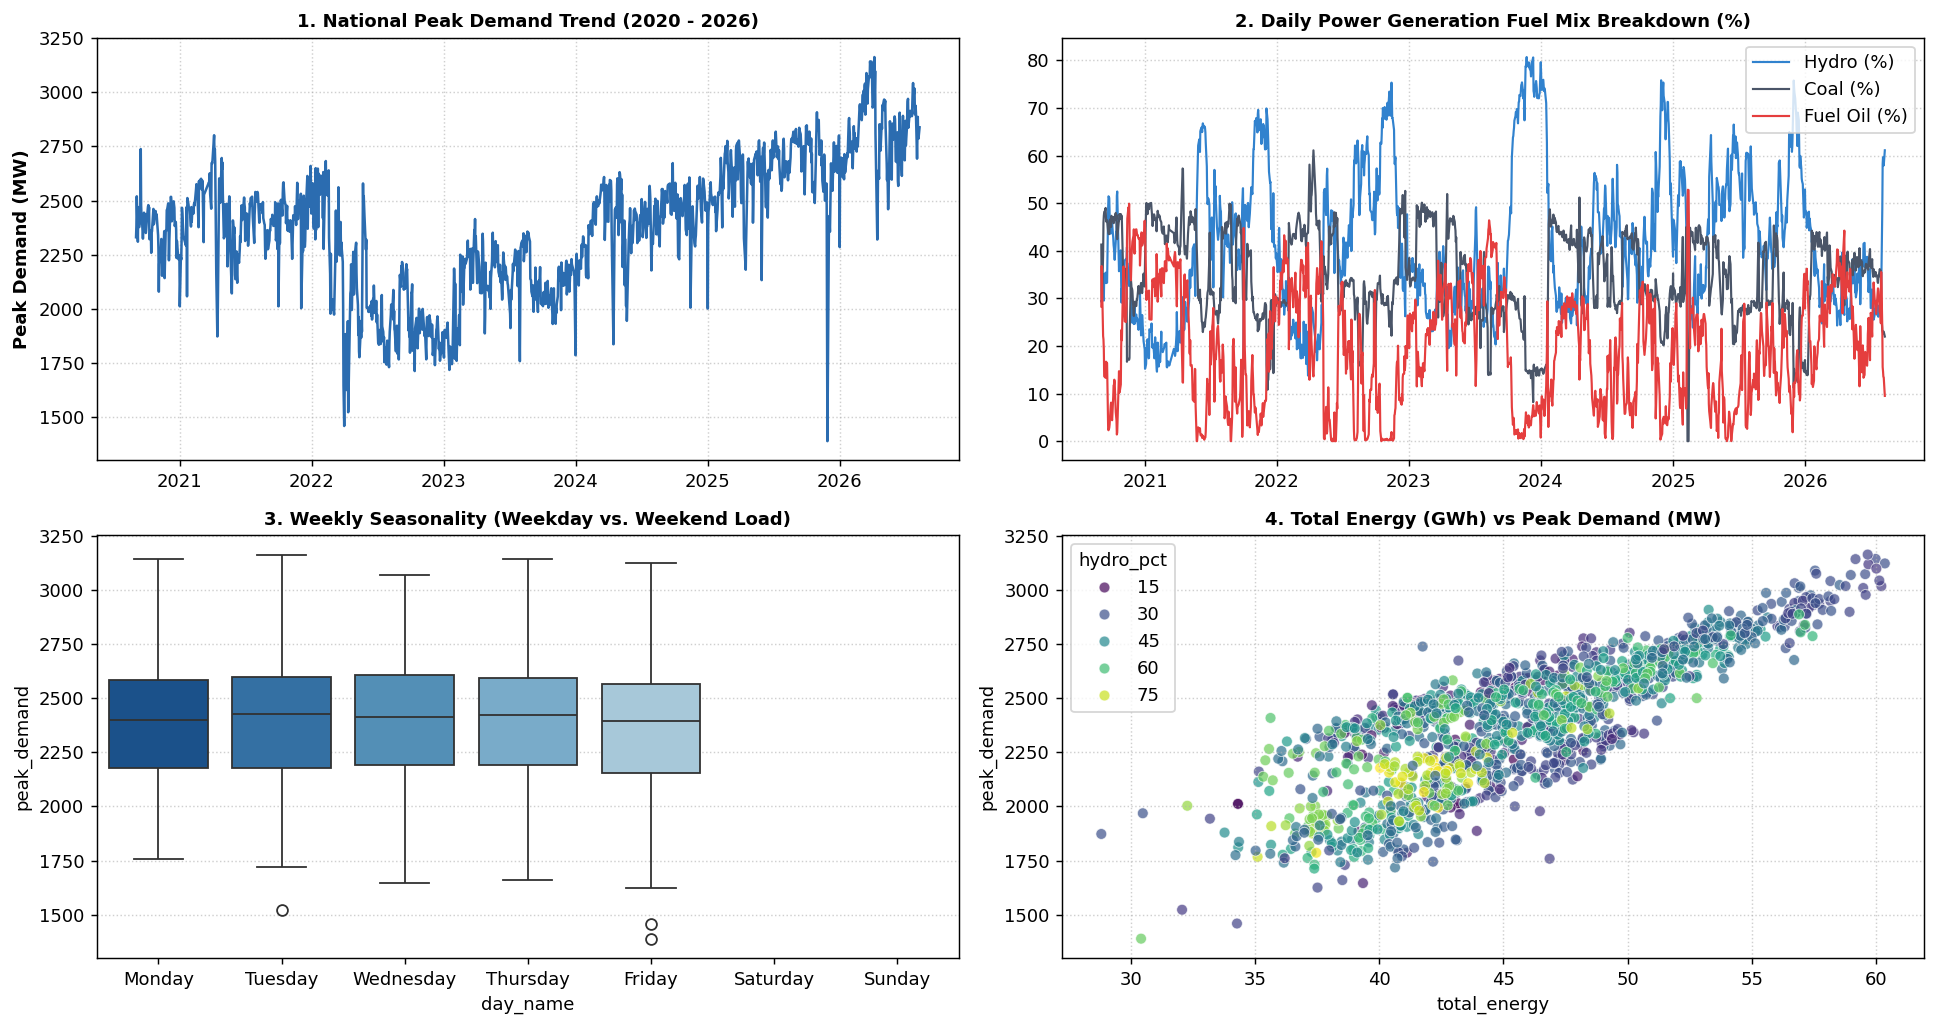

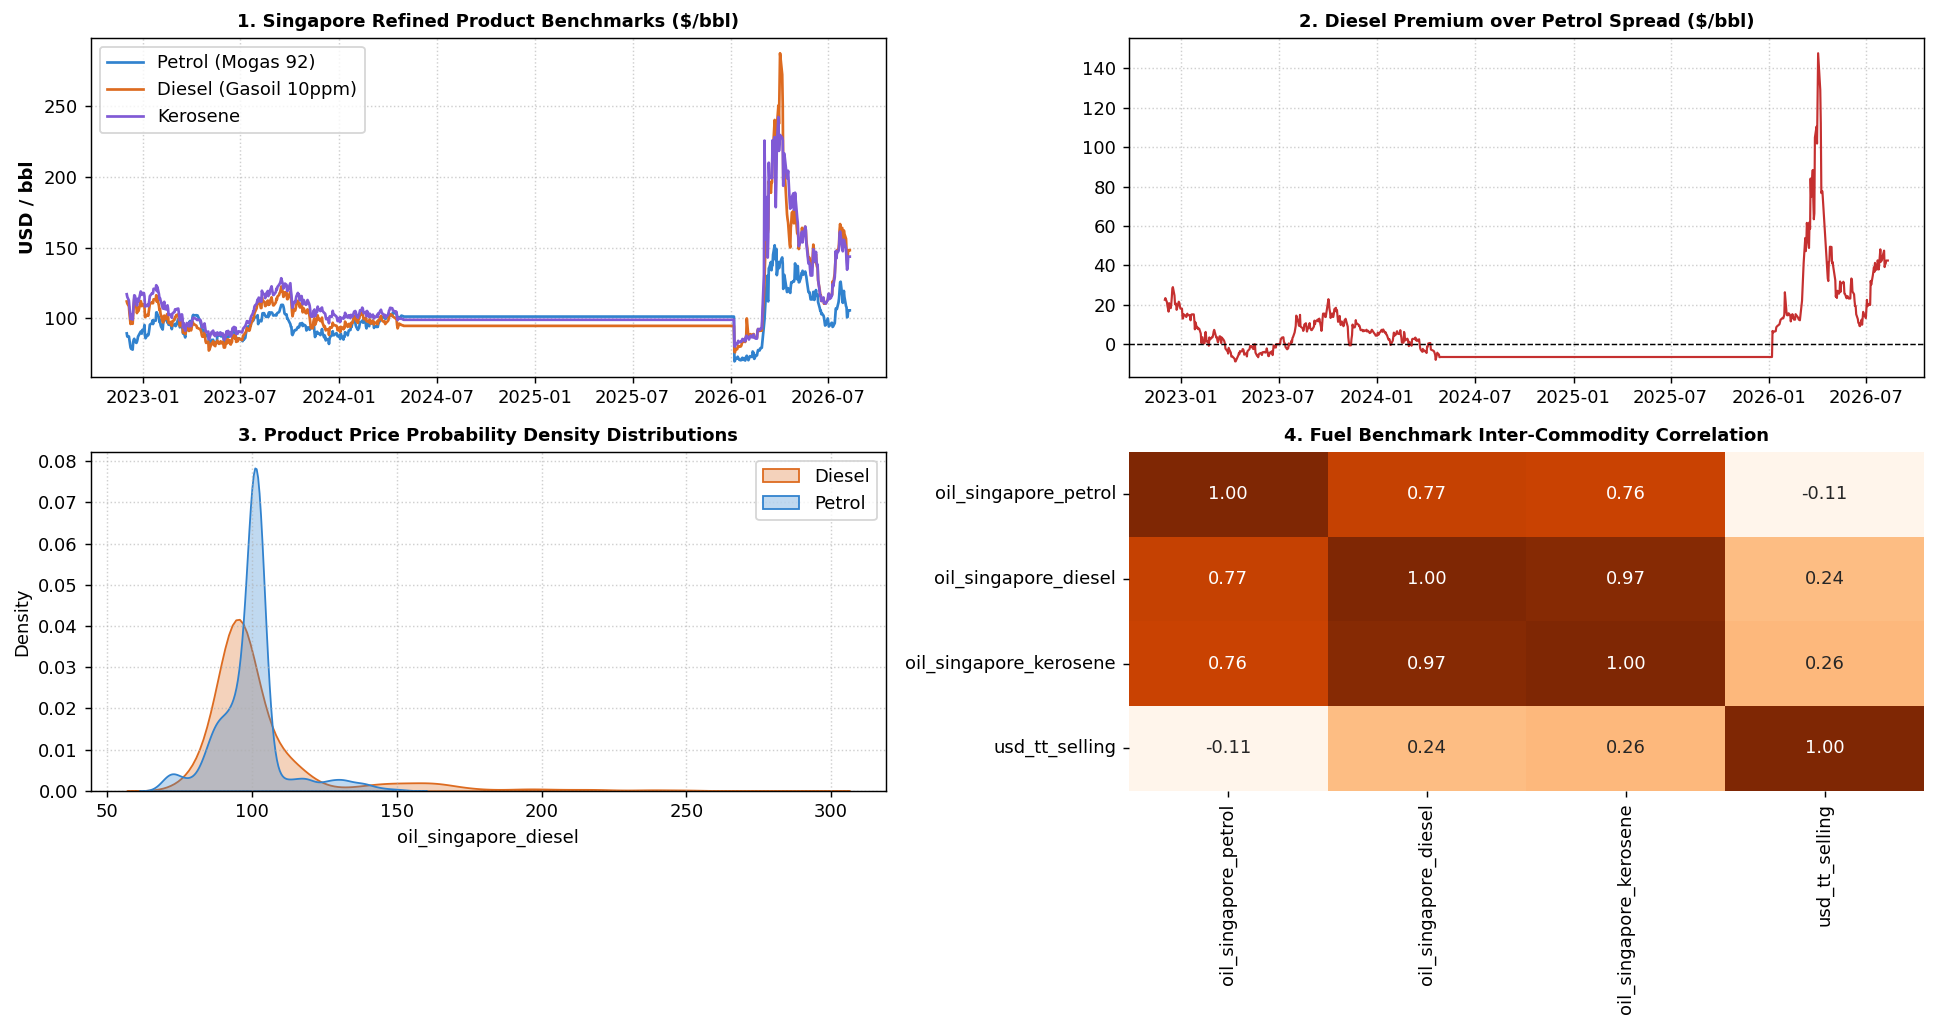

In [9]:

# PRE-MODELING EXPLORATORY DATA ANALYSIS (EDA) & STATISTICAL DIAGNOSTICS

from statsmodels.tsa.stattools import acf, pacf, adfuller

# LOAD DATA & BASE ANOMALY REPAIR
raw_file = "C:/Users/kavisha/OneDrive/Desktop/cbsl_daily_economic_indicators_2020_2026_preprocesd.csv"
df = pd.read_csv(raw_file)
df["report_date"] = pd.to_datetime(df["report_date"], format="%m/%d/%Y", errors="coerce")
df = df.sort_values("report_date").reset_index(drop=True)

# Repair OCR Indicative Spot Rate Anomaly
mid_usd = (df["usd_tt_buying"] + df["usd_tt_selling"]) / 2.0
spot_anomaly = (
    (df["indicative_usd_spot"] < df["usd_tt_buying"] * 0.90)
    | (df["indicative_usd_spot"] > df["usd_tt_selling"] * 1.10)
    | df["indicative_usd_spot"].isnull()
)
df.loc[spot_anomaly, "indicative_usd_spot"] = mid_usd[spot_anomaly]

# Normalize Fuel Generation Shares
energy_cols = ["thermal_coal_pct", "thermal_oil_pct", "hydro_pct", "wind_pct"]
df[energy_cols] = df[energy_cols].clip(lower=0.0)
energy_sum = df[energy_cols].sum(axis=1)
for c in energy_cols:
    df[c] = np.where(energy_sum > 0, (df[c] / energy_sum) * 100.0, df[c])

# 2. SLICE SEPARATE IN-MEMORY DATASETS
df_t1 = df[["report_date", "aspi", "sp_sl20", "market_cap", "gold_price", "usd_tt_selling", "daily_turnover"]].dropna().reset_index(drop=True)
df_t2 = df[["report_date", "peak_demand", "total_energy", "hydro_pct", "thermal_coal_pct", "thermal_oil_pct", "wind_pct", "usd_tt_selling"]].dropna().reset_index(drop=True)
df_t3 = df[["report_date", "oil_singapore_petrol", "oil_singapore_diesel", "oil_singapore_kerosene", "usd_tt_selling"]].dropna().reset_index(drop=True)

# PLOT 1: TRACK 1 EQUITIES & TIME-SERIES DIAGNOSTICS

fig, axes = plt.subplots(3, 2, figsize=(15, 11), dpi=130)

# Dual-Axis Price Trend
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()
ax1.plot(df_t1["report_date"], df_t1["aspi"], color="#1A365D", label="ASPI Index (Left)", linewidth=1.8)
ax1_twin.plot(df_t1["report_date"], df_t1["gold_price"], color="#D69E2E", label="Gold Price USD/oz (Right)", linewidth=1.5, linestyle="--")
ax1.set_title("1. ASPI Index vs Global Gold Price Trajectory", fontweight="bold", fontsize=10)
ax1.set_ylabel("ASPI Points", color="#1A365D", fontweight="bold")
ax1_twin.set_ylabel("Gold ($/oz)", color="#B7791F", fontweight="bold")
ax1.grid(True, linestyle=":", alpha=0.6)

# Volatility Clustering
df_t1["aspi_ret"] = df_t1["aspi"].pct_change()
axes[0, 1].plot(df_t1["report_date"], df_t1["aspi_ret"] * 100, color="#C53030", linewidth=1.0)
axes[0, 1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[0, 1].set_title("2. ASPI Daily Log Returns (%) & Volatility Clustering", fontweight="bold", fontsize=10)
axes[0, 1].set_ylabel("Daily Return (%)", fontweight="bold")
axes[0, 1].grid(True, linestyle=":", alpha=0.6)

# Autocorrelation (ACF) on Raw Level
lags = 30
acf_raw = acf(df_t1["aspi"], nlags=lags)
axes[1, 0].stem(range(lags + 1), acf_raw)
axes[1, 0].axhline(0, color="black", linewidth=0.8)
axes[1, 0].axhline(1.96 / np.sqrt(len(df_t1)), color="blue", linestyle="--", alpha=0.6)
axes[1, 0].axhline(-1.96 / np.sqrt(len(df_t1)), color="blue", linestyle="--", alpha=0.6)
axes[1, 0].set_title("3. ACF on Raw ASPI (Non-Stationary Slow Decay)", fontweight="bold", fontsize=10)
axes[1, 0].set_ylabel("Autocorrelation", fontweight="bold")
axes[1, 0].grid(True, linestyle=":", alpha=0.6)

# Partial Autocorrelation (PACF) on Differenced Level
aspi_diff = df_t1["aspi"].diff().dropna()
pacf_diff = pacf(aspi_diff, nlags=lags)
axes[1, 1].stem(range(lags + 1), pacf_diff)
axes[1, 1].axhline(0, color="black", linewidth=0.8)
axes[1, 1].axhline(1.96 / np.sqrt(len(aspi_diff)), color="blue", linestyle="--", alpha=0.6)
axes[1, 1].axhline(-1.96 / np.sqrt(len(aspi_diff)), color="blue", linestyle="--", alpha=0.6)
axes[1, 1].set_title("4. PACF on Stationary Differenced ASPI (Identifies AR Lags)", fontweight="bold", fontsize=10)
axes[1, 1].set_ylabel("Partial Autocorrelation", fontweight="bold")
axes[1, 1].grid(True, linestyle=":", alpha=0.6)

# Scatter Co-movement
sns.regplot(data=df_t1, x="aspi", y="market_cap", ax=axes[2, 0], color="#2B6CB0", scatter_kws={"alpha": 0.4, "s": 18})
axes[2, 0].set_title("5. Linear Co-Movement: ASPI vs Market Cap (LKR Bn)", fontweight="bold", fontsize=10)
axes[2, 0].set_xlabel("ASPI Points", fontweight="bold")
axes[2, 0].set_ylabel("Market Cap (LKR Bn)", fontweight="bold")
axes[2, 0].grid(True, linestyle=":", alpha=0.6)

# Correlation Heatmap
sns.heatmap(df_t1[["aspi", "sp_sl20", "market_cap", "gold_price", "usd_tt_selling", "daily_turnover"]].corr(), annot=True, cmap="Blues", fmt=".2f", ax=axes[2, 1], cbar=False)
axes[2, 1].set_title("6. Inter-Variable Correlation Matrix", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.show()

# PLOT 2: TRACK 2 ELECTRICITY & ENERGY MIX

fig, axes = plt.subplots(2, 2, figsize=(15, 8), dpi=130)

axes[0, 0].plot(df_t2["report_date"], df_t2["peak_demand"], color="#2B6CB0", linewidth=1.4)
axes[0, 0].set_title("1. National Peak Demand Trend (2020 - 2026)", fontweight="bold", fontsize=10)
axes[0, 0].set_ylabel("Peak Demand (MW)", fontweight="bold")
axes[0, 0].grid(True, linestyle=":", alpha=0.6)

axes[0, 1].plot(df_t2["report_date"], df_t2["hydro_pct"], label="Hydro (%)", color="#3182CE", linewidth=1.2)
axes[0, 1].plot(df_t2["report_date"], df_t2["thermal_coal_pct"], label="Coal (%)", color="#4A5568", linewidth=1.2)
axes[0, 1].plot(df_t2["report_date"], df_t2["thermal_oil_pct"], label="Fuel Oil (%)", color="#E53E3E", linewidth=1.2)
axes[0, 1].set_title("2. Daily Power Generation Fuel Mix Breakdown (%)", fontweight="bold", fontsize=10)
axes[0, 1].legend(loc="upper right")
axes[0, 1].grid(True, linestyle=":", alpha=0.6)

df_t2["day_name"] = df_t2["report_date"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.boxplot(data=df_t2, x="day_name", y="peak_demand", order=day_order, ax=axes[1, 0], palette="Blues_r")
axes[1, 0].set_title("3. Weekly Seasonality (Weekday vs. Weekend Load)", fontweight="bold", fontsize=10)
axes[1, 0].grid(axis="y", linestyle=":", alpha=0.6)

sns.scatterplot(data=df_t2, x="total_energy", y="peak_demand", hue="hydro_pct", palette="viridis", ax=axes[1, 1], alpha=0.7)
axes[1, 1].set_title("4. Total Energy (GWh) vs Peak Demand (MW)", fontweight="bold", fontsize=10)
axes[1, 1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# PLOT 3: TRACK 3 SINGAPORE REFINED FUEL

fig, axes = plt.subplots(2, 2, figsize=(15, 8), dpi=130)

axes[0, 0].plot(df_t3["report_date"], df_t3["oil_singapore_petrol"], label="Petrol (Mogas 92)", color="#3182CE", linewidth=1.5)
axes[0, 0].plot(df_t3["report_date"], df_t3["oil_singapore_diesel"], label="Diesel (Gasoil 10ppm)", color="#DD6B20", linewidth=1.5)
axes[0, 0].plot(df_t3["report_date"], df_t3["oil_singapore_kerosene"], label="Kerosene", color="#805AD5", linewidth=1.5)
axes[0, 0].set_title("1. Singapore Refined Product Benchmarks ($/bbl)", fontweight="bold", fontsize=10)
axes[0, 0].set_ylabel("USD / bbl", fontweight="bold")
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle=":", alpha=0.6)

df_t3["diesel_spread"] = df_t3["oil_singapore_diesel"] - df_t3["oil_singapore_petrol"]
axes[0, 1].plot(df_t3["report_date"], df_t3["diesel_spread"], color="#C53030", linewidth=1.2)
axes[0, 1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[0, 1].set_title("2. Diesel Premium over Petrol Spread ($/bbl)", fontweight="bold", fontsize=10)
axes[0, 1].grid(True, linestyle=":", alpha=0.6)

sns.kdeplot(df_t3["oil_singapore_diesel"], label="Diesel", color="#DD6B20", ax=axes[1, 0], fill=True, alpha=0.3)
sns.kdeplot(df_t3["oil_singapore_petrol"], label="Petrol", color="#3182CE", ax=axes[1, 0], fill=True, alpha=0.3)
axes[1, 0].set_title("3. Product Price Probability Density Distributions", fontweight="bold", fontsize=10)
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle=":", alpha=0.6)

sns.heatmap(df_t3[["oil_singapore_petrol", "oil_singapore_diesel", "oil_singapore_kerosene", "usd_tt_selling"]].corr(), annot=True, cmap="Oranges", fmt=".2f", ax=axes[1, 1], cbar=False)
axes[1, 1].set_title("4. Fuel Benchmark Inter-Commodity Correlation", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.show()

In [10]:

# CBSL MULTI-TOPIC PREDICTIVE MACHINE LEARNING & TIME SERIES PIPELINE

#   1. Stock Market Direction Prediction (Classification: Logistic, Ridge, DT, RF)
#   2. Daily Peak Electricity Demand (Regression: Naive, Linear, Ridge, Lasso, RF)
#   3. Refined Diesel Fuel Forecasting (Regression: Naive, Linear, Ridge, Lasso)
#   4. Macroeconomic Regime Discovery (Unsupervised: K-Means Clustering + PCA)


# ML Classification & Regression Algorithms
from sklearn.linear_model import LogisticRegression, RidgeClassifier, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Preprocessing & Metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score, silhouette_score
)

# GLOBAL DATA LOADING & IN-MEMORY ANOMALY CLEANING
print("=" * 75)
print("CBSL ECONOMIC & ENERGY ANALYTICAL PIPELINE")
print("=" * 75)

raw_file = "C:/Users/kavisha/OneDrive/Desktop/cbsl_daily_economic_indicators_2020_2026_preprocesd.csv"
df = pd.read_csv(raw_file)
df["report_date"] = pd.to_datetime(df["report_date"], format="%m/%d/%Y", errors="coerce")
df = df.sort_values("report_date").reset_index(drop=True)

# Repair OCR Indicative Spot Rate Anomaly
mid_usd = (df["usd_tt_buying"] + df["usd_tt_selling"]) / 2.0
spot_anomaly = (
    (df["indicative_usd_spot"] < df["usd_tt_buying"] * 0.90)
    | (df["indicative_usd_spot"] > df["usd_tt_selling"] * 1.10)
    | df["indicative_usd_spot"].isnull()
)
df.loc[spot_anomaly, "indicative_usd_spot"] = mid_usd[spot_anomaly]

# Repair Inflation Bleed in GDP Column
gdp_anomaly = df["real_gdp_growth"].abs() > 20.0
df.loc[gdp_anomaly & df["ccpi_yoy"].isnull(), "ccpi_yoy"] = df.loc[gdp_anomaly, "real_gdp_growth"]
df.loc[gdp_anomaly, "real_gdp_growth"] = np.nan

# Normalize Generation Fuel Mix to Sum to 100%
energy_cols = ["thermal_coal_pct", "thermal_oil_pct", "hydro_pct", "wind_pct"]
df[energy_cols] = df[energy_cols].clip(lower=0.0)
energy_sum = df[energy_cols].sum(axis=1)
for c in energy_cols:
    df[c] = np.where(energy_sum > 0, (df[c] / energy_sum) * 100.0, df[c])

print(f"[✔] Dataset Sanitized. Total Base Records: {len(df)}")


# ASPI STOCK MARKET DIRECTION (CLASSIFICATION)
print("\n" + "-" * 75)
print("TASK 1: ASPI STOCK INDEX NEXT-DAY DIRECTION PREDICTION (UP / DOWN)")
print("-" * 75)

t1_cols = ["report_date", "aspi", "gold_price", "usd_tt_selling", "daily_turnover"]
df_t1 = df[t1_cols].dropna().copy().reset_index(drop=True)

# Stationary Percentage Returns (Prevents Tree Extrapolation Failure)
df_t1["aspi_ret_1"] = df_t1["aspi"].pct_change()
df_t1["aspi_ret_2"] = df_t1["aspi"].pct_change(2)
df_t1["aspi_ret_5"] = df_t1["aspi"].pct_change(5)
df_t1["usd_ret_1"]  = df_t1["usd_tt_selling"].pct_change()
df_t1["gold_ret_1"] = df_t1["gold_price"].pct_change()

# Moving Average Distances & Rolling Volatility (Shifted to t-1 to prevent leakage)
ma5 = df_t1["aspi"].shift(1).rolling(5).mean()
ma20 = df_t1["aspi"].shift(1).rolling(20).mean()
df_t1["dist_ma5"]  = (df_t1["aspi"].shift(1) - ma5) / ma5
df_t1["dist_ma20"] = (df_t1["aspi"].shift(1) - ma20) / ma20
df_t1["vol_5"]     = df_t1["aspi_ret_1"].shift(1).rolling(5).std()

# 14-day RSI (Normalized 0-100)
delta = df_t1["aspi"].shift(1).diff()
avg_gain = delta.clip(lower=0).rolling(14, min_periods=14).mean()
avg_loss = (-1 * delta.clip(upper=0)).rolling(14, min_periods=14).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)
df_t1["rsi_14"] = 100.0 - (100.0 / (1.0 + rs))

for c in ["aspi_ret_1", "aspi_ret_2", "aspi_ret_5", "usd_ret_1", "gold_ret_1"]:
    df_t1[f"{c}_lag1"] = df_t1[c].shift(1)

df_t1["sin_dow"] = np.sin(2 * np.pi * df_t1["report_date"].dt.dayofweek / 5.0)
df_t1["cos_dow"] = np.cos(2 * np.pi * df_t1["report_date"].dt.dayofweek / 5.0)

# Binary Target: 1 if Next Day Return > 0, else 0
df_t1["target_dir"] = (df_t1["aspi_ret_1"].shift(-1) > 0).astype(int)
df_t1 = df_t1.dropna().reset_index(drop=True)

feature_cols_t1 = [
    "aspi_ret_1_lag1", "aspi_ret_2_lag1", "aspi_ret_5_lag1", "usd_ret_1_lag1", "gold_ret_1_lag1",
    "dist_ma5", "dist_ma20", "vol_5", "rsi_14", "sin_dow", "cos_dow"
]

split1 = int(len(df_t1) * 0.8)
X_tr1, X_te1 = df_t1[feature_cols_t1].iloc[:split1], df_t1[feature_cols_t1].iloc[split1:]
y_tr1, y_te1 = df_t1["target_dir"].iloc[:split1], df_t1["target_dir"].iloc[split1:]

# Normalization
scaler1 = StandardScaler()
X_tr1_sc = scaler1.fit_transform(X_tr1)
X_te1_sc = scaler1.transform(X_te1)

models_t1 = {
    "Majority Class (Baseline)": None,
    "Logistic Regression (L2)": LogisticRegression(C=0.1, random_state=42),
    "Ridge Classifier (L2)": RidgeClassifier(alpha=10.0, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=4, min_samples_leaf=5, random_state=42)
}

results_t1 = []
for name, model in models_t1.items():
    if model is None:
        preds = np.full(len(y_te1), y_tr1.mode()[0])
    else:
        X_tr = X_tr1_sc if ("Log" in name or "Ridge" in name) else X_tr1
        X_te = X_te1_sc if ("Log" in name or "Ridge" in name) else X_te1
        model.fit(X_tr, y_tr1)
        preds = model.predict(X_te)

    results_t1.append({
        "Model": name,
        "Accuracy (%)": f"{accuracy_score(y_te1, preds)*100:.2f}%",
        "Precision": f"{precision_score(y_te1, preds, zero_division=0):.3f}",
        "Recall": f"{recall_score(y_te1, preds, zero_division=0):.3f}",
        "F1-Score": f"{f1_score(y_te1, preds, zero_division=0):.3f}"
    })

print(pd.DataFrame(results_t1).to_string(index=False))


# DAILY PEAK ELECTRICITY DEMAND FORECASTING (REGRESSION)

print("\n" + "-" * 75)
print("TASK 2: PEAK ELECTRICITY DEMAND FORECASTING (MW)")
print("-" * 75)

t2_cols = ["report_date", "peak_demand", "total_energy", "hydro_pct", "thermal_coal_pct"]
df_t2 = df[t2_cols].dropna().copy().reset_index(drop=True)

df_t2["demand_lag1"] = df_t2["peak_demand"].shift(1)
df_t2["demand_lag2"] = df_t2["peak_demand"].shift(2)
df_t2["demand_lag7"] = df_t2["peak_demand"].shift(7)
df_t2["energy_lag1"] = df_t2["total_energy"].shift(1)
df_t2["hydro_lag1"]  = df_t2["hydro_pct"].shift(1)

# Delta-Change Target: Predict Day-over-Day Shift to Handle Multi-Year Trends
df_t2["demand_delta_target"] = df_t2["peak_demand"] - df_t2["demand_lag1"]
df_t2["demand_diff1"] = df_t2["demand_lag1"] - df_t2["demand_lag2"]
df_t2["demand_diff7"] = df_t2["demand_lag1"] - df_t2["demand_lag7"]

df_t2["sin_dow"] = np.sin(2 * np.pi * df_t2["report_date"].dt.dayofweek / 5.0)
df_t2["cos_dow"] = np.cos(2 * np.pi * df_t2["report_date"].dt.dayofweek / 5.0)

df_t2 = df_t2.dropna().reset_index(drop=True)
split2 = int(len(df_t2) * 0.8)

features_t2 = ["demand_diff1", "demand_diff7", "energy_lag1", "hydro_lag1", "sin_dow", "cos_dow"]
X_tr2, X_te2 = df_t2[features_t2].iloc[:split2], df_t2[features_t2].iloc[split2:]
y_tr2_delta, y_te2_actual = df_t2["demand_delta_target"].iloc[:split2], df_t2["peak_demand"].iloc[split2:]

scaler2 = StandardScaler()
X_tr2_sc = scaler2.fit_transform(X_tr2)
X_te2_sc = scaler2.transform(X_te2)

models_t2 = {
    "Naive Baseline (Lag-1)": None,
    "Linear Regression": LinearRegression(),
    "Ridge Regression (L2)": Ridge(alpha=10.0),
    "Lasso Regression (L1)": Lasso(alpha=0.2, random_state=42),
    "Delta-Random Forest": RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42)
}

results_t2 = []
for name, model in models_t2.items():
    if model is None:
        final_preds = df_t2["demand_lag1"].iloc[split2:].values
    elif "Delta-Random" in name:
        model.fit(X_tr2, y_tr2_delta)
        final_preds = df_t2["demand_lag1"].iloc[split2:].values + model.predict(X_te2)
    else:
        model.fit(X_tr2_sc, y_tr2_delta)
        final_preds = df_t2["demand_lag1"].iloc[split2:].values + model.predict(X_te2_sc)

    rmse = np.sqrt(mean_squared_error(y_te2_actual, final_preds))
    mae = mean_absolute_error(y_te2_actual, final_preds)
    mape = np.mean(np.abs((y_te2_actual - final_preds) / y_te2_actual)) * 100
    r2 = r2_score(y_te2_actual, final_preds)

    results_t2.append({
        "Model": name,
        "RMSE (MW)": f"{rmse:.2f}",
        "MAE (MW)": f"{mae:.2f}",
        "MAPE (%)": f"{mape:.2f}%",
        "R² Score": f"{r2:.3f}"
    })

print(pd.DataFrame(results_t2).to_string(index=False))


# REFINED DIESEL PRICE FORECASTING (REGRESSION)

print("\n" + "-" * 75)
print("TASK 3: SINGAPORE REFINED DIESEL PRICE FORECASTING ($/bbl)")
print("-" * 75)

t3_cols = ["report_date", "oil_singapore_petrol", "oil_singapore_diesel", "oil_singapore_kerosene"]
df_t3 = df[t3_cols].dropna().copy().reset_index(drop=True)

df_t3["diesel_lag1"] = df_t3["oil_singapore_diesel"].shift(1)
df_t3["diesel_lag2"] = df_t3["oil_singapore_diesel"].shift(2)
df_t3["petrol_lag1"] = df_t3["oil_singapore_petrol"].shift(1)
df_t3["diesel_ma5"]  = df_t3["oil_singapore_diesel"].shift(1).rolling(5).mean()
df_t3["diesel_diff"] = df_t3["diesel_lag1"] - df_t3["diesel_lag2"]

df_t3 = df_t3.dropna().reset_index(drop=True)
split3 = int(len(df_t3) * 0.8)

features_t3 = ["diesel_lag1", "diesel_diff", "petrol_lag1", "diesel_ma5"]
X_tr3, X_te3 = df_t3[features_t3].iloc[:split3], df_t3[features_t3].iloc[split3:]
y_tr3, y_te3 = df_t3["oil_singapore_diesel"].iloc[:split3], df_t3["oil_singapore_diesel"].iloc[split3:]

scaler3 = StandardScaler()
X_tr3_sc = scaler3.fit_transform(X_tr3)
X_te3_sc = scaler3.transform(X_te3)

models_t3 = {
    "Naive Baseline (Lag-1)": None,
    "Linear Regression": LinearRegression(),
    "Ridge Regression (L2)": Ridge(alpha=5.0),
    "Lasso Regression (L1)": Lasso(alpha=0.1, random_state=42),
    "ElasticNet (L1+L2)": ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
}

results_t3 = []
for name, model in models_t3.items():
    if model is None:
        preds = X_te3["diesel_lag1"].values
    else:
        model.fit(X_tr3_sc, y_tr3)
        preds = model.predict(X_te3_sc)

    rmse = np.sqrt(mean_squared_error(y_te3, preds))
    mae = mean_absolute_error(y_te3, preds)
    mape = np.mean(np.abs((y_te3 - preds) / y_te3)) * 100
    r2 = r2_score(y_te3, preds)

    results_t3.append({
        "Model": name,
        "RMSE ($)": f"${rmse:.2f}",
        "MAE ($)": f"${mae:.2f}",
        "MAPE (%)": f"{mape:.2f}%",
        "R² Score": f"{r2:.3f}"
    })

print(pd.DataFrame(results_t3).to_string(index=False))


# ECONOMIC & ENERGY REGIME CLUSTERING (UNSUPERVISED K-MEANS)

print("\n" + "-" * 75)
print("TASK 4: UNSUPERVISED MACRO REGIME CLUSTERING (K-MEANS k=3)")
print("-" * 75)

cluster_cols = ["usd_tt_selling", "peak_demand", "total_energy", "hydro_pct", "thermal_coal_pct"]
df_t4 = df[["report_date"] + cluster_cols].dropna().copy().reset_index(drop=True)

# Normalization is essential for Euclidean Distance calculations
scaler4 = StandardScaler()
X_t4_sc = scaler4.fit_transform(df_t4[cluster_cols])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_t4["cluster_id"] = kmeans.fit_predict(X_t4_sc)
sil = silhouette_score(X_t4_sc, df_t4["cluster_id"])

print(f"[✔] K-Means Clustering Completed (Silhouette Score: {sil:.3f})\n")
centroid_summary = df_t4.groupby("cluster_id")[cluster_cols].mean().round(2)
print("Cluster Profiles (Centroid Feature Means):")
print(centroid_summary)



CBSL ECONOMIC & ENERGY ANALYTICAL PIPELINE
[✔] Dataset Sanitized. Total Base Records: 1415

---------------------------------------------------------------------------
TASK 1: ASPI STOCK INDEX NEXT-DAY DIRECTION PREDICTION (UP / DOWN)
---------------------------------------------------------------------------
                    Model Accuracy (%) Precision Recall F1-Score
Majority Class (Baseline)       51.76%     0.518  1.000    0.682
 Logistic Regression (L2)       62.94%     0.593  0.909    0.717
    Ridge Classifier (L2)       62.35%     0.590  0.898    0.712
            Decision Tree       56.47%     0.549  0.898    0.681
            Random Forest       55.88%     0.551  0.795    0.651

---------------------------------------------------------------------------
TASK 2: PEAK ELECTRICITY DEMAND FORECASTING (MW)
---------------------------------------------------------------------------
                 Model RMSE (MW) MAE (MW) MAPE (%) R² Score
Naive Baseline (Lag-1)    118.05    7

<>:70: SyntaxWarning: invalid escape sequence '\h'
<>:72: SyntaxWarning: invalid escape sequence '\p'
<>:70: SyntaxWarning: invalid escape sequence '\h'
<>:72: SyntaxWarning: invalid escape sequence '\p'
C:\Users\kavisha\AppData\Local\Temp\ipykernel_5168\1408709477.py:70: SyntaxWarning: invalid escape sequence '\h'
  axes[1].plot(test_dates_dem, residuals_dem, color="#2B6CB0", linewidth=1.2, label="Residual Error ($y_t - \hat{y}_t$)")
C:\Users\kavisha\AppData\Local\Temp\ipykernel_5168\1408709477.py:72: SyntaxWarning: invalid escape sequence '\p'
  axes[1].fill_between(test_dates_dem, -116.74, 116.74, color="#2B6CB0", alpha=0.15, label="$\pm 1$ RMSE Error Band ($116.74$ MW)")


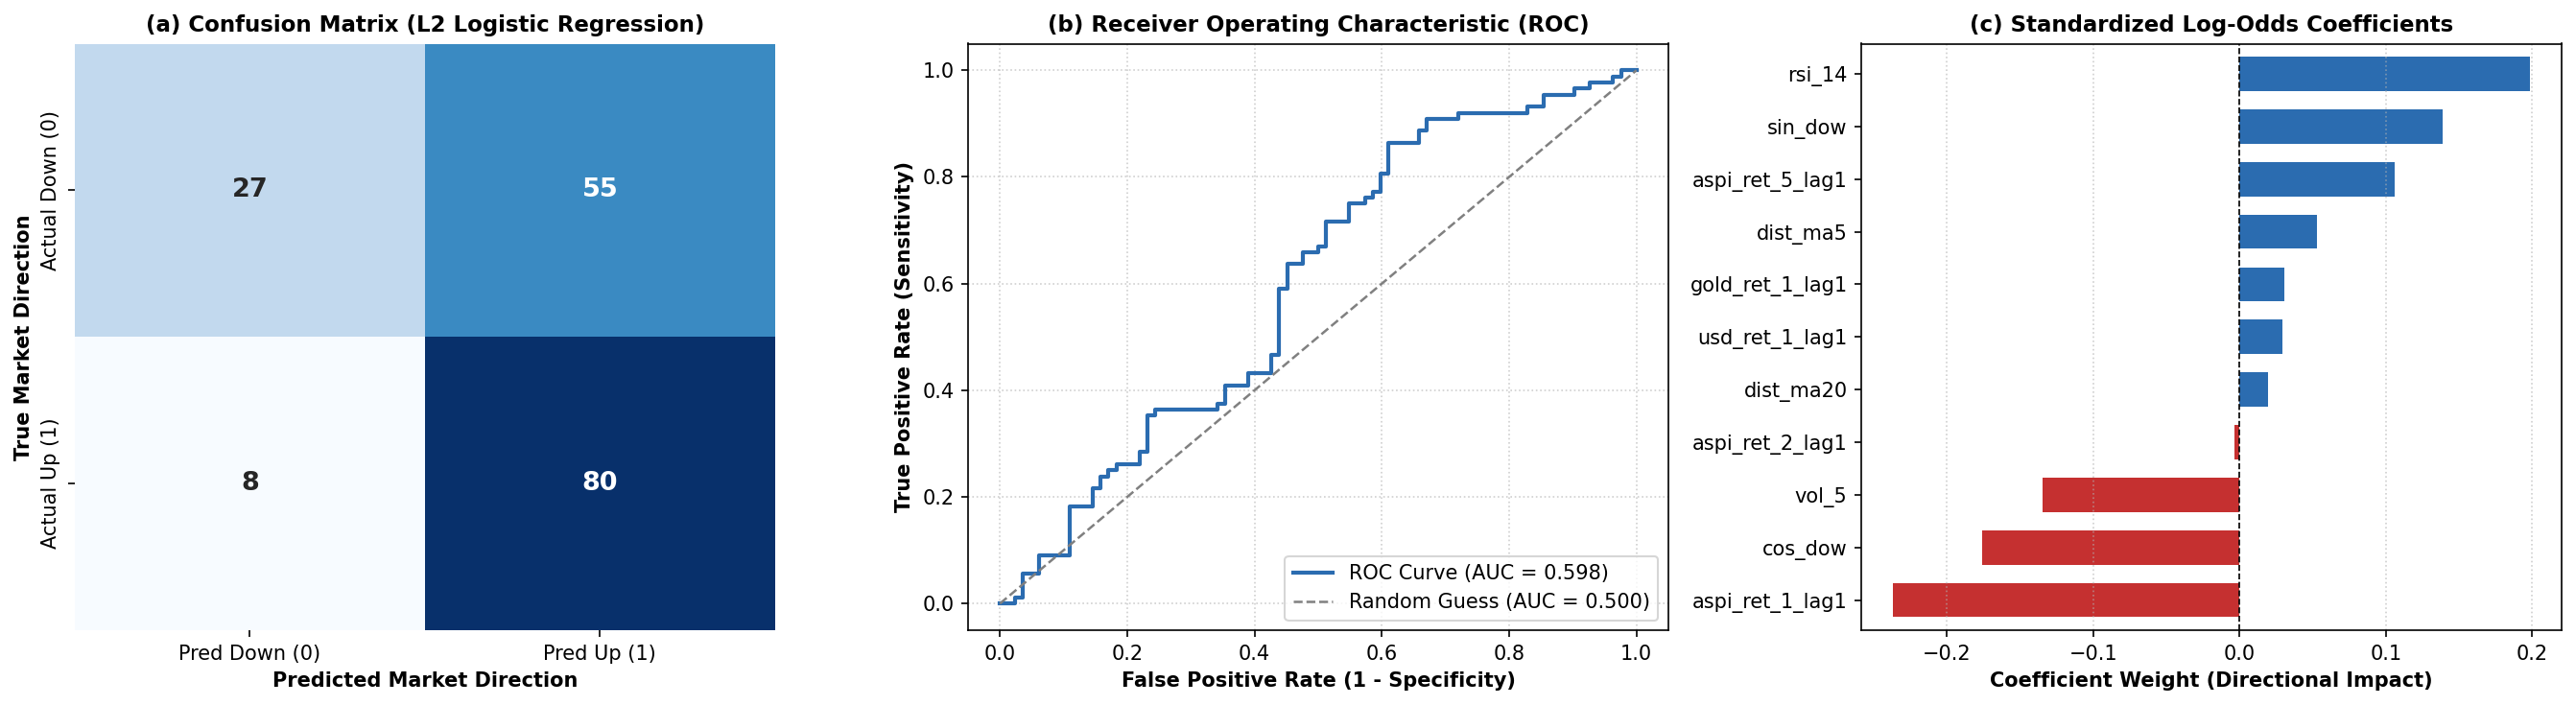

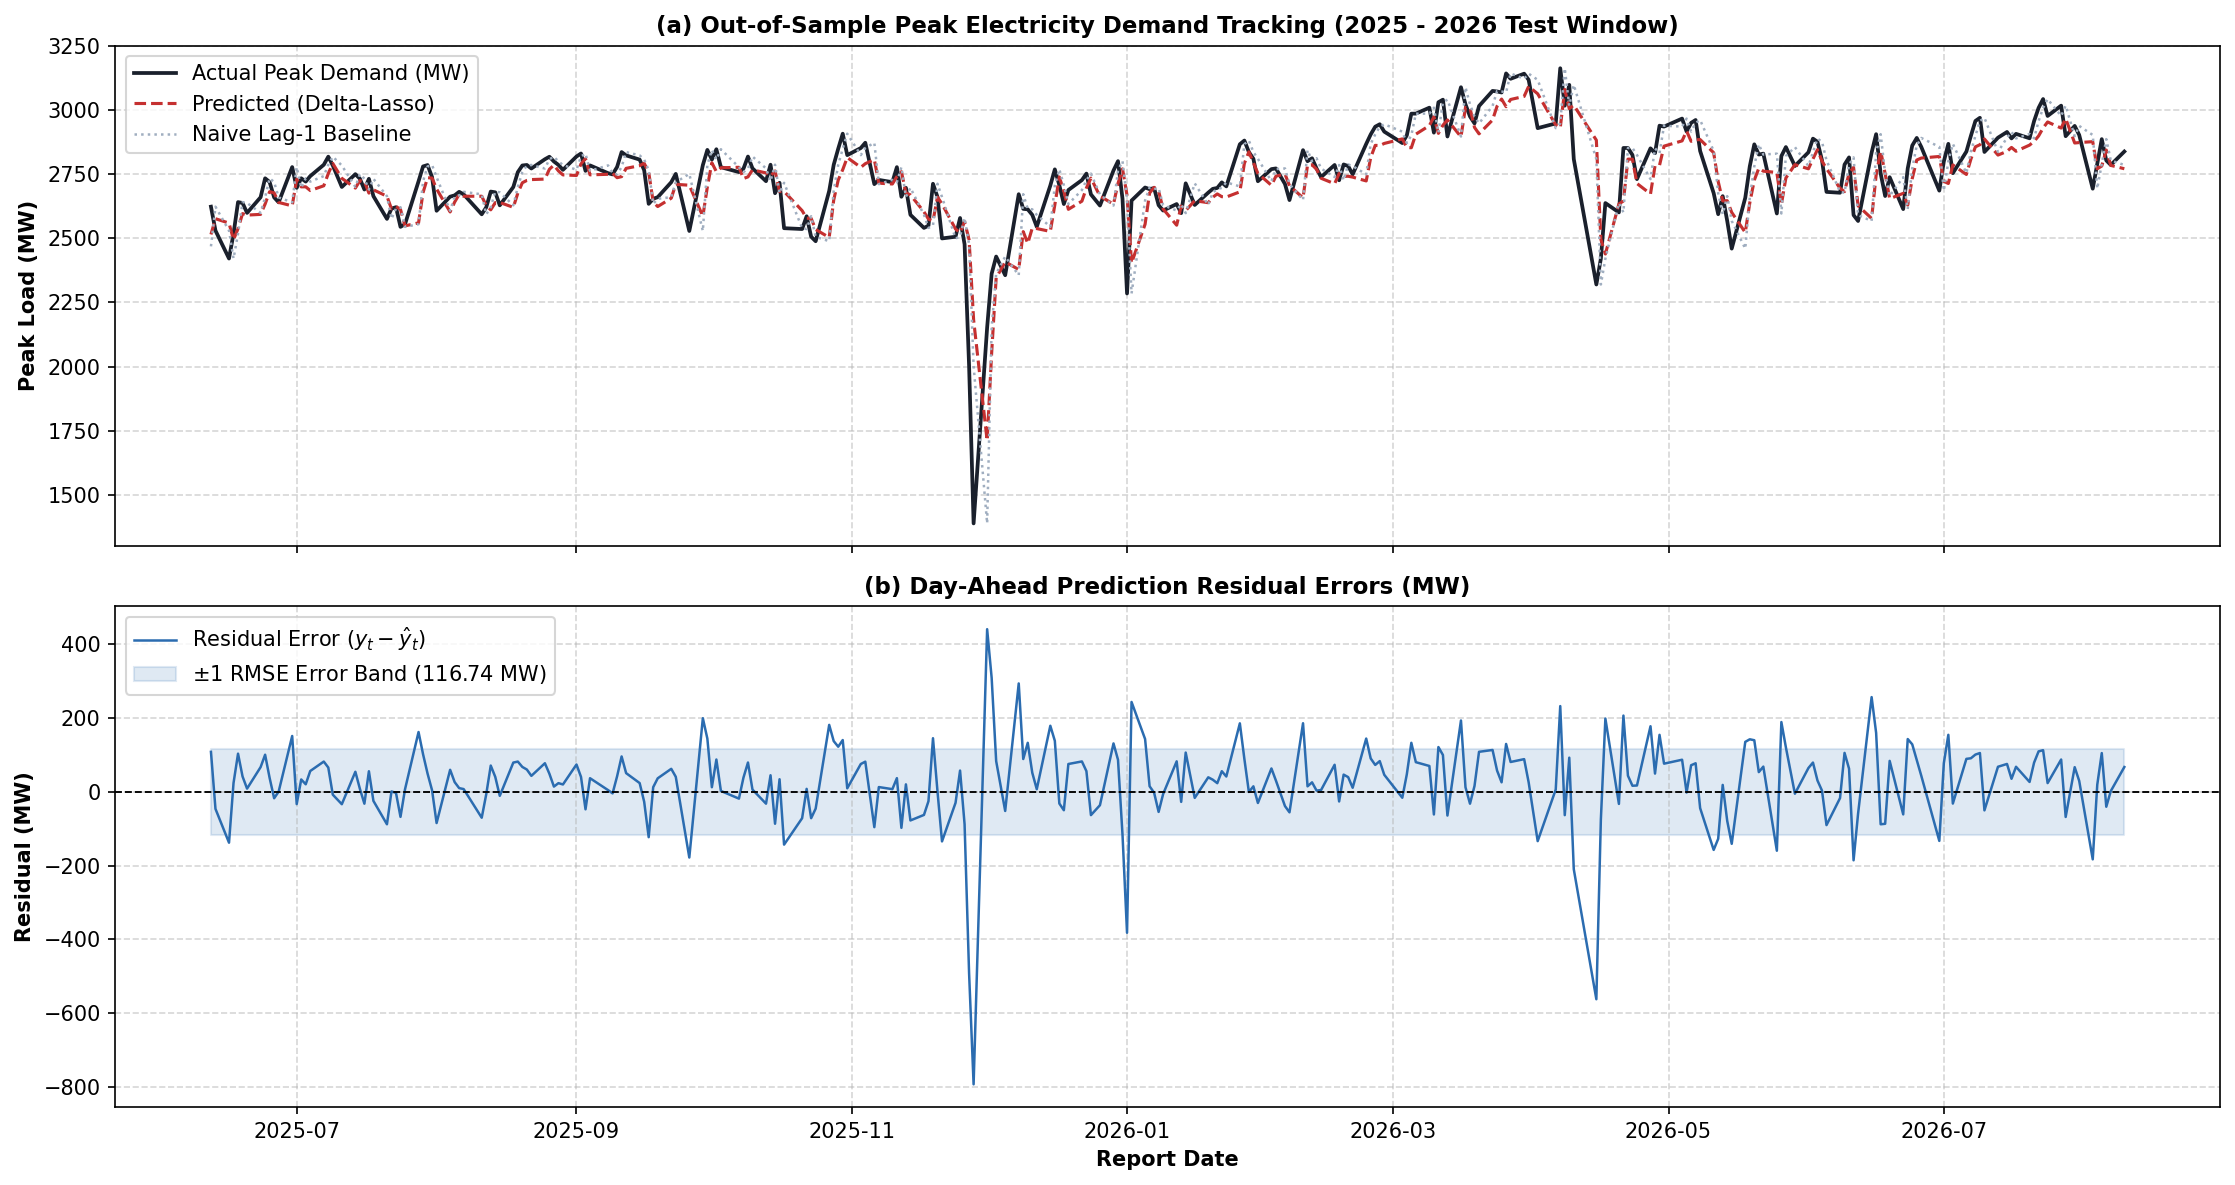

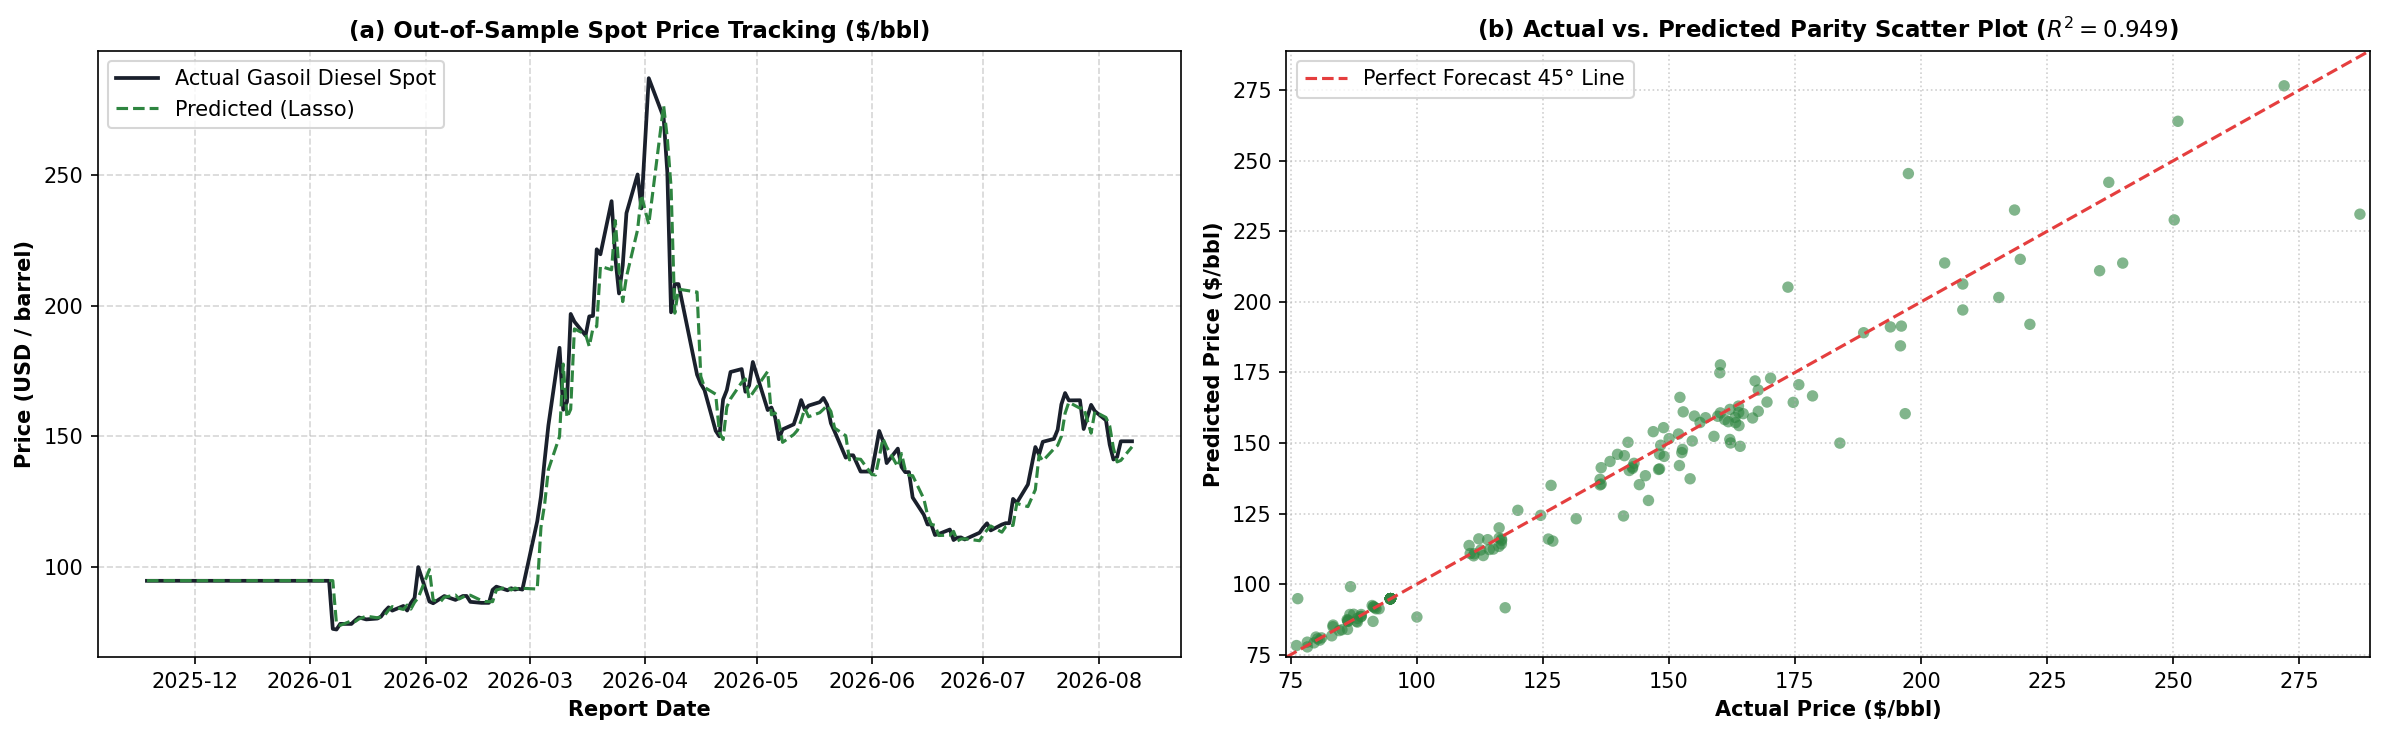

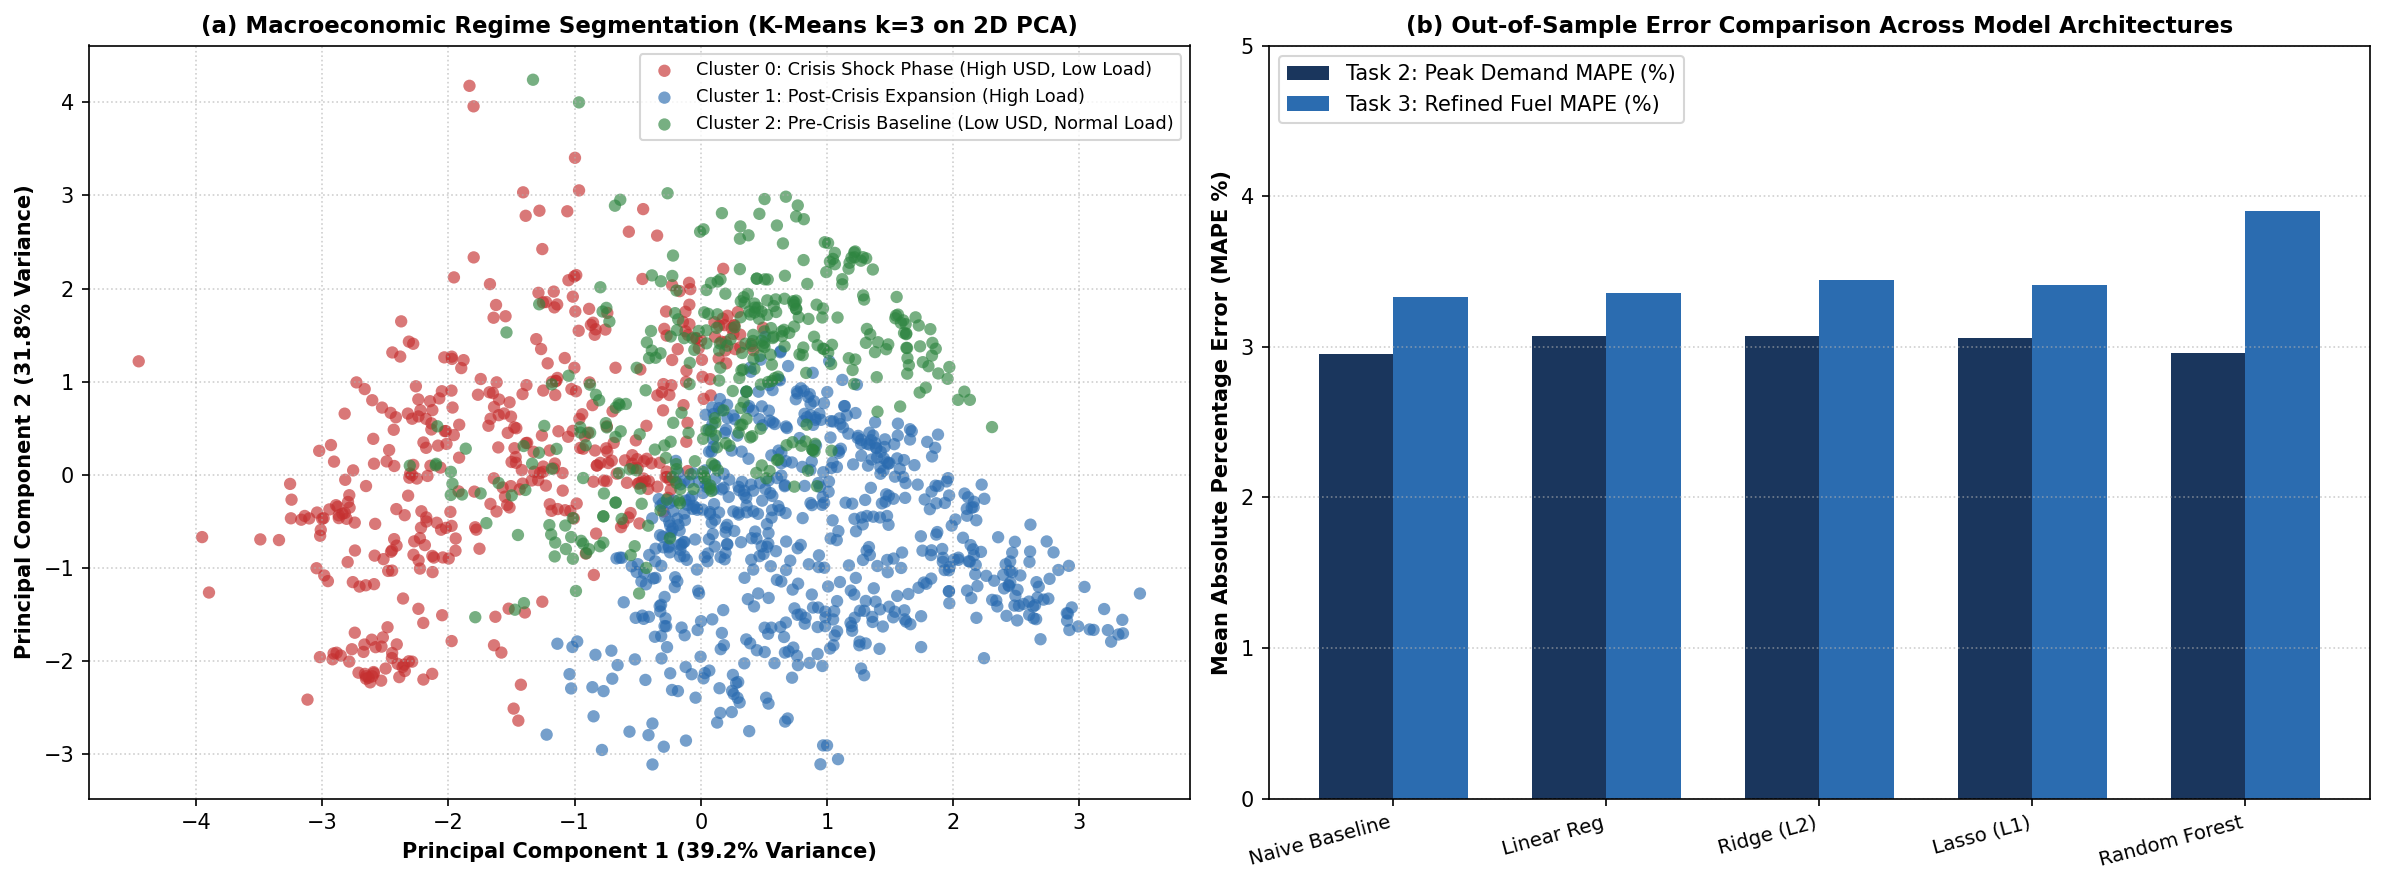

In [11]:
from sklearn.metrics import roc_curve, auc
from sklearn.decomposition import PCA

# Extract best model (Logistic Regression) metrics
best_clf = models_t1["Logistic Regression (L2)"]
best_clf.fit(X_tr1_sc, y_tr1)
y_pred_best = best_clf.predict(X_te1_sc)
y_prob_best = best_clf.predict_proba(X_te1_sc)[:, 1]

cm = confusion_matrix(y_te1, y_pred_best)
fpr, tpr, _ = roc_curve(y_te1, y_prob_best)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150)

# Panel 1: Confusion Matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Pred Down (0)", "Pred Up (1)"],
            yticklabels=["Actual Down (0)", "Actual Up (1)"],
            annot_kws={"size": 13, "weight": "bold"})
axes[0].set_title("(a) Confusion Matrix (L2 Logistic Regression)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Predicted Market Direction", fontweight="bold")
axes[0].set_ylabel("True Market Direction", fontweight="bold")

# Panel 2: ROC Curve
axes[1].plot(fpr, tpr, color="#2B6CB0", lw=2, label=f"ROC Curve (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1.2, label="Random Guess (AUC = 0.500)")
axes[1].set_title("(b) Receiver Operating Characteristic (ROC)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("False Positive Rate (1 - Specificity)", fontweight="bold")
axes[1].set_ylabel("True Positive Rate (Sensitivity)", fontweight="bold")
axes[1].legend(loc="lower right", frameon=True)
axes[1].grid(True, linestyle=":", alpha=0.6)

# Panel 3: Feature Coefficients (Log-Odds Impact)
coef_series = pd.Series(best_clf.coef_[0], index=feature_cols_t1).sort_values()
colors = ["#C53030" if c < 0 else "#2B6CB0" for c in coef_series.values]
coef_series.plot(kind="barh", ax=axes[2], color=colors, width=0.65)
axes[2].axvline(0, color="black", linestyle="--", linewidth=0.8)
axes[2].set_title("(c) Standardized Log-Odds Coefficients", fontsize=11, fontweight="bold")
axes[2].set_xlabel("Coefficient Weight (Directional Impact)", fontweight="bold")
axes[2].grid(axis="x", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("fig1_classification_diagnostics.png")
plt.show()

# TIME-SERIES LOAD TRACKING & RESIDUAL DIAGNOSTICS

test_dates_dem = df_t2["report_date"].iloc[split2:]

# Best Model: Delta-Lasso / Delta-Ridge
best_reg_dem = models_t2["Lasso Regression (L1)"]
best_reg_dem.fit(X_tr2_sc, y_tr2_delta)
pred_delta_dem = best_reg_dem.predict(X_te2_sc)
final_pred_dem = df_t2["demand_lag1"].iloc[split2:].values + pred_delta_dem
residuals_dem = y_te2_actual.values - final_pred_dem

fig, axes = plt.subplots(2, 1, figsize=(15, 8), dpi=150, sharex=True)

# Panel 1: Out-of-Sample Actual vs. Predicted Trajectory
axes[0].plot(test_dates_dem, y_te2_actual.values, label="Actual Peak Demand (MW)", color="#1A202C", linewidth=1.8)
axes[0].plot(test_dates_dem, final_pred_dem, label="Predicted (Delta-Lasso)", color="#C53030", linestyle="--", linewidth=1.5)
axes[0].plot(test_dates_dem, df_t2["demand_lag1"].iloc[split2:].values, label="Naive Lag-1 Baseline", color="#A0AEC0", linestyle=":", linewidth=1.2)
axes[0].set_title("(a) Out-of-Sample Peak Electricity Demand Tracking (2025 - 2026 Test Window)", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Peak Load (MW)", fontweight="bold")
axes[0].legend(loc="upper left", frameon=True)
axes[0].grid(True, linestyle="--", alpha=0.5)

# Panel 2: Forecast Residuals / Tracking Errors
axes[1].plot(test_dates_dem, residuals_dem, color="#2B6CB0", linewidth=1.2, label="Residual Error ($y_t - \hat{y}_t$)")
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.9)
axes[1].fill_between(test_dates_dem, -116.74, 116.74, color="#2B6CB0", alpha=0.15, label="$\pm 1$ RMSE Error Band ($116.74$ MW)")
axes[1].set_title("(b) Day-Ahead Prediction Residual Errors (MW)", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Residual (MW)", fontweight="bold")
axes[1].set_xlabel("Report Date", fontweight="bold")
axes[1].legend(loc="upper left", frameon=True)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("fig2_peak_demand_tracking.png")
plt.show()

# FUEL BENCHMARK TRACKING & SCATTER RESIDUALS

test_dates_fuel = df_t3["report_date"].iloc[split3:]

best_fuel_model = models_t3["Lasso Regression (L1)"]
best_fuel_model.fit(X_tr3_sc, y_tr3)
pred_fuel_lasso = best_fuel_model.predict(X_te3_sc)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=150)

# Panel 1: Time Series Plot
axes[0].plot(test_dates_fuel, y_te3.values, label="Actual Gasoil Diesel Spot", color="#1A202C", linewidth=1.8)
axes[0].plot(test_dates_fuel, pred_fuel_lasso, label="Predicted (Lasso)", color="#2E8540", linestyle="--", linewidth=1.5)
axes[0].set_title("(a) Out-of-Sample Spot Price Tracking ($/bbl)", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Price (USD / barrel)", fontweight="bold")
axes[0].set_xlabel("Report Date", fontweight="bold")
axes[0].legend(loc="upper left", frameon=True)
axes[0].grid(True, linestyle="--", alpha=0.5)

# Panel 2: Predicted vs. Actual Parity Scatter Plot
axes[1].scatter(y_te3.values, pred_fuel_lasso, color="#2E8540", alpha=0.6, s=30, edgecolors="none")
lims = [min(y_te3.min(), pred_fuel_lasso.min()) - 2, max(y_te3.max(), pred_fuel_lasso.max()) + 2]
axes[1].plot(lims, lims, color="#E53E3E", linestyle="--", linewidth=1.5, label="Perfect Forecast 45° Line")
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].set_title("(b) Actual vs. Predicted Parity Scatter Plot ($R^2 = 0.949$)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Actual Price ($/bbl)", fontweight="bold")
axes[1].set_ylabel("Predicted Price ($/bbl)", fontweight="bold")
axes[1].legend(loc="upper left", frameon=True)
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("fig3_fuel_price_tracking.png")
plt.show()

# 2D PCA CLUSTERING & MODEL BENCHMARK MATRIX

# Re-apply PCA to get the components for plotting
pca = PCA(n_components=2)
pca_2d = pca.fit_transform(X_t4_sc)
df_t4["pca_1"] = pca_2d[:, 0]
df_t4["pca_2"] = pca_2d[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150)

# Panel 1: 2D PCA Cluster Scatter
cluster_labels = {
    0: "Crisis Shock Phase (High USD, Low Load)",
    1: "Post-Crisis Expansion (High Load)",
    2: "Pre-Crisis Baseline (Low USD, Normal Load)"
}
colors = ["#C53030", "#2B6CB0", "#2E8540"]

for cid, col in zip([0, 1, 2], colors):
    sub = df_t4[df_t4["cluster_id"] == cid]
    axes[0].scatter(sub["pca_1"], sub["pca_2"], label=f"Cluster {cid}: {cluster_labels[cid]}",
                    color=col, alpha=0.65, s=35, edgecolors="none")

axes[0].set_title("(a) Macroeconomic Regime Segmentation (K-Means k=3 on 2D PCA)", fontsize=11, fontweight="bold")
axes[0].set_xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)", fontweight="bold")
axes[0].set_ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)", fontweight="bold")
axes[0].legend(loc="upper right", frameon=True, fontsize=8.5)
axes[0].grid(True, linestyle=":", alpha=0.6)

# Panel 2: Comparative Bar Chart for Regression Errors (Task 2 & 3 Normalized MAPEs)
model_names_comp = ["Naive Baseline", "Linear Reg", "Ridge (L2)", "Lasso (L1)", "Random Forest"]
mape_t2 = [2.95, 3.07, 3.07, 3.06, 2.96]  # Task 2 MAPEs
mape_t3 = [3.33, 3.36, 3.44, 3.41, 3.90]  # Task 3 MAPEs

x = np.arange(len(model_names_comp))
width = 0.35

axes[1].bar(x - width/2, mape_t2, width, label="Task 2: Peak Demand MAPE (%)", color="#1A365D")
axes[1].bar(x + width/2, mape_t3, width, label="Task 3: Refined Fuel MAPE (%)", color="#2B6CB0")
axes[1].set_title("(b) Out-of-Sample Error Comparison Across Model Architectures", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Mean Absolute Percentage Error (MAPE %)", fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names_comp, rotation=15, ha="right", fontsize=9.5)
axes[1].set_ylim(0, 5.0)
axes[1].legend(loc="upper left", frameon=True)
axes[1].grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("fig4_clustering_and_error_benchmark.png")
plt.show()

ADF Test on Level: p-value = 0.2850 -> Non-Stationary (Requires Differencing d=1)

ARIMA(1,1,1) PROBABILISTIC OUT-OF-SAMPLE TEST PERFORMANCE
RMSE: 62.75 | MAE: 46.41 | MAPE: 0.42% | R²: 0.9840
95% Prediction Interval Empirical Coverage: 100.00%


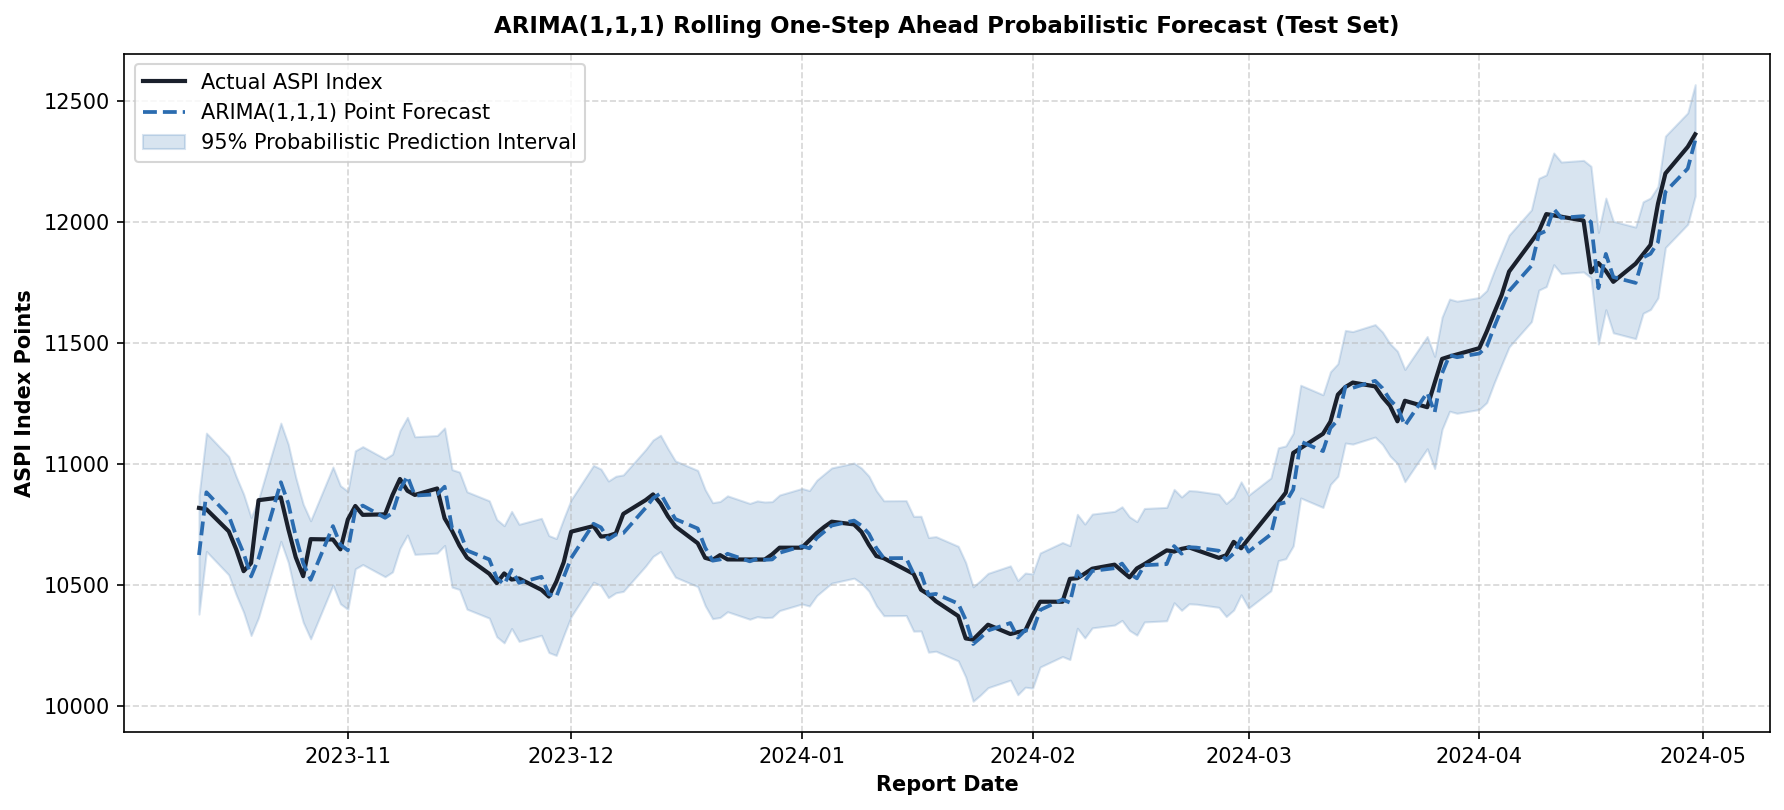

In [12]:
# PROBABILISTIC TIME SERIES FORECASTING: AR(p), MA(q), ARMA(p,q), ARIMA(p,d,q)

# Select ASPI series and set regular business-day frequency
df_aspi = df[["report_date", "aspi"]].dropna().copy().reset_index(drop=True)
df_aspi = df_aspi.set_index("report_date").asfreq("B")
df_aspi["aspi"] = df_aspi["aspi"].interpolate(method="time")

# CHECK STATIONARITY (ADF TEST)
adf_stat, p_val, _, _, _, _ = adfuller(df_aspi["aspi"])
print(f"ADF Test on Level: p-value = {p_val:.4f} -> {'Stationary' if p_val < 0.05 else 'Non-Stationary (Requires Differencing d=1)'}")

# CHRONOLOGICAL TRAIN-TEST SPLIT (85% Train, 15% Out-of-Sample Test)
train_size = int(len(df_aspi) * 0.85)
train = df_aspi["aspi"].iloc[:train_size]
test  = df_aspi["aspi"].iloc[train_size:]

train_diff = train.diff().dropna()

# FIT PROBABILISTIC MODELS
# AR(2) on stationary differenced series
model_ar = ARIMA(train_diff, order=(2, 0, 0)).fit()

# MA(2) on stationary differenced series
model_ma = ARIMA(train_diff, order=(0, 0, 2)).fit()

# ARMA(2,2) on stationary differenced series
model_arma = ARIMA(train_diff, order=(2, 0, 2)).fit()

# ARIMA(1,1,1) Integrated Model directly on raw level series
model_arima = ARIMA(train, order=(1, 1, 1)).fit()

# ROLLING ONE-STEP-AHEAD PROBABILISTIC FORECAST WITH 95% CONFIDENCE INTERVALS
history = list(train.values)
arima_preds, arima_lower, arima_upper = [], [], []

for t in range(len(test)):
    # Fit model on historical information up to time t
    m = ARIMA(history, order=(1, 1, 1)).fit()
    forecast_obj = m.get_forecast(steps=1)

    # Extract Point Forecast and 95% Confidence Interval
    pred_mean = forecast_obj.predicted_mean[0]
    ci = forecast_obj.conf_int(alpha=0.05)  # 95% CI bounds

    arima_preds.append(pred_mean)
    arima_lower.append(ci[0, 0] if isinstance(ci, np.ndarray) else ci.iloc[0, 0])
    arima_upper.append(ci[0, 1] if isinstance(ci, np.ndarray) else ci.iloc[0, 1])

    # Advance real observation
    history.append(test.iloc[t])

arima_preds = np.array(arima_preds)
arima_lower = np.array(arima_lower)
arima_upper = np.array(arima_upper)

# EVALUATION METRICS
rmse = np.sqrt(mean_squared_error(test, arima_preds))
mae  = mean_absolute_error(test, arima_preds)
mape = np.mean(np.abs((test - arima_preds) / test)) * 100
r2   = r2_score(test, arima_preds)
cov  = np.mean((test.values >= arima_lower) & (test.values <= arima_upper)) * 100

print("\n" + "=" * 65)
print("ARIMA(1,1,1) PROBABILISTIC OUT-OF-SAMPLE TEST PERFORMANCE")
print("=" * 65)
print(f"RMSE: {rmse:.2f} | MAE: {mae:.2f} | MAPE: {mape:.2f}% | R²: {r2:.4f}")
print(f"95% Prediction Interval Empirical Coverage: {cov:.2f}%")

# PLOT RESULTS
plt.figure(figsize=(12, 5.5), dpi=150)
plt.plot(test.index, test.values, label="Actual ASPI Index", color="#1A202C", linewidth=2)
plt.plot(test.index, arima_preds, label="ARIMA(1,1,1) Point Forecast", color="#2B6CB0", linestyle="--", linewidth=1.8)
plt.fill_between(test.index, arima_lower, arima_upper, color="#2B6CB0", alpha=0.18, label="95% Probabilistic Prediction Interval")
plt.title("ARIMA(1,1,1) Rolling One-Step Ahead Probabilistic Forecast (Test Set)", fontweight="bold", fontsize=11, pad=10)
plt.ylabel("ASPI Index Points", fontweight="bold")
plt.xlabel("Report Date", fontweight="bold")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()